# Evaluation for `HexnerModGame` (Amortized) When P2 has stochastic dynamics unknown to P1

This notebook evaluates a pretrained amortized policy under **state-observation noise**.

Setup:
- P2 has new dynamics `y_t = x_t + noise_t` unknown to P1. 
- At each step, P1 **re-solves** the primal game from `(y_t, p_t)`.
- P2 control is computed from the same local solve, using true state by default.
- Compare against  resolve vs no resolve receding-horizon baseline.

This directly tests deployment-time robustness to noisy state observations (not prior-shift adaptation).


In [118]:
import os
import sys
import time
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

# Add repo root to path (works from notebooks/ or repo root)
CWD = os.getcwd()
if os.path.basename(CWD) == "notebooks":
    REPO_ROOT = os.path.abspath(os.path.join(CWD, ".."))
else:
    REPO_ROOT = CWD
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Repo root:", REPO_ROOT)


Repo root: /Users/mghimire/Research/MPC_2p0s1


In [104]:
from MPC_2p0s1.config.base_config import GameConfig, project_relative
from MPC_2p0s1.core.action_spaces import BoxActionSpace
from MPC_2p0s1.games.hexner_mod_game import HexnerModGame, HexnerModParams
import MPC_2p0s1.outer_opt.amortized_alpha as amortized_alpha_mod
from MPC_2p0s1.outer_opt.amortized_alpha import (
    AmortizedAlphaConfig,
    AmortizedAlphaParam,
    primal_objective_from_alpha,
)
from MPC_2p0s1.tree.indexing import FullIaryTreeIndexer
from MPC_2p0s1.tree.rollout import rollout_trajectory
from MPC_2p0s1.viz.visualization_mod import (
    plot_hexner_mod_context,
    plot_hexner_mod_trajectory,
)

# compile objective for faster resolve
# @torch._dynamo.dont_skip_tracing()
# def apply_compile(fn):
#     return fn

# primal_objective_from_alpha = apply_compile(primal_objective_from_alpha)

In [105]:
# Runtime config

device = torch.device("cpu")
# CHECKPOINT_PATH = project_relative("runs/hexner_mod_amortized/latest.pt")
CHECKPOINT_PATH = project_relative("runs/hexner_mod_amortized_long/latest.pt")

print(f"Checkpoint: {CHECKPOINT_PATH}")


def _resolve_dtype(dtype_obj):
    if isinstance(dtype_obj, torch.dtype):
        return dtype_obj
    if isinstance(dtype_obj, str):
        key = dtype_obj.replace("torch.", "")
        if hasattr(torch, key):
            return getattr(torch, key)
    return torch.float32


def _rebuild_game_config(meta_dict: Dict) -> GameConfig:
    cfg = GameConfig()
    for k, v in meta_dict.items():
        setattr(cfg, k, v)

    if not hasattr(cfg, "dx"):
        cfg.dx = cfg.dx1 + cfg.dx2
    if not hasattr(cfg, "tau") and hasattr(cfg, "T") and hasattr(cfg, "K"):
        cfg.tau = cfg.T / cfg.K

    cfg.device = str(device)
    cfg.device_resolved = device
    cfg.dtype = _resolve_dtype(getattr(cfg, "dtype", torch.float32))
    return cfg


def _parse_tuple_floats(raw):
    if isinstance(raw, (list, tuple)):
        return tuple(float(v) for v in raw)
    return tuple(float(v.strip()) for v in str(raw).split(",") if v.strip())


def _parse_tuple_ints(raw):
    if isinstance(raw, (list, tuple)):
        return tuple(int(v) for v in raw)
    return tuple(int(v.strip()) for v in str(raw).split(",") if v.strip())


Checkpoint: /Users/mghimire/Research/MPC_2p0s1/runs/hexner_mod_amortized_long/latest.pt


In [106]:
payload = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
meta = payload.get("meta", {})
args_ckpt = meta.get("args", {})

if "model_state_dict" not in payload:
    raise RuntimeError(
        "Checkpoint does not contain 'model_state_dict'. "
        "Use a checkpoint produced by train_hexner_mod_amortized.py."
    )

game_cfg = _rebuild_game_config(meta.get("game_config", {}))
indexer = FullIaryTreeIndexer(I=game_cfg.I, K=game_cfg.K)

hidden_dims = _parse_tuple_ints(args_ckpt.get("hidden_dims", "256,256"))
amort_cfg = AmortizedAlphaConfig(
    hidden_dims=hidden_dims,
    activation=str(args_ckpt.get("activation", "silu")),
    dropout=float(args_ckpt.get("dropout", 0.0)),
)

model = AmortizedAlphaParam(
    indexer=indexer,
    dx=game_cfg.dx,
    I=game_cfg.I,
    cfg=amort_cfg,
    dtype=game_cfg.dtype,
    device=device,
)
model.load_state_dict(payload["model_state_dict"])
model.eval()

params = HexnerModParams(
    theta_values=_parse_tuple_floats(args_ckpt.get("theta_values", "-1.0,1.0")),
    target_z=None,
    R1_scale=float(args_ckpt.get("R1_scale", 1.0)),
    R2_scale=float(args_ckpt.get("R2_scale", 0.4)),
    K1_scale=float(args_ckpt.get("K1_scale", 1.0)),
    K2_scale=float(args_ckpt.get("K2_scale", 1.0)),
)

game = HexnerModGame(cfg=game_cfg, params=params, prior=None)
# action_space = BoxActionSpace.from_config(game_cfg)
action_space = None

# Notebook compatibility if riccati_backward is decorated with torch.compile remove
# if hasattr(amortized_alpha_mod.riccati_backward, "__wrapped__"):
#     amortized_alpha_mod.riccati_backward = amortized_alpha_mod.riccati_backward.__wrapped__
#     print("Patched to uncompiled riccati_backward for notebook compatibility.")

print(
    f"Loaded checkpoint: step={meta.get('step', '?')}, "
    f"train_loss={meta.get('train_loss', '?')}, eval_loss={meta.get('eval_loss', '?')}"
)
print(f"Game: I={game_cfg.I}, K={game_cfg.K}, T={game_cfg.T}, dtype={game_cfg.dtype}")
print(f"Model: hidden_dims={hidden_dims}, activation={amort_cfg.activation}, dropout={amort_cfg.dropout}")


Loaded checkpoint: step=4999, train_loss=0.09126466512680054, eval_loss=0.06202588975429535
Game: I=2, K=10, T=1.0, dtype=torch.float32
Model: hidden_dims=(64,), activation=silu, dropout=0.0


In [173]:

dtype = game_cfg.dtype
base_x0 = game.default_initial_state().to(device=device, dtype=dtype)

def make_x0(
    p1x=-1.0, p1y=0.0, p1vx=0.0, p1vy=0.0,
    p2x=1.0, p2y=0.0, p2vx=0.0, p2vy=0.0,
):
    return torch.tensor(
        [p1x, p1y, p1vx, p1vy, p2x, p2y, p2vx, p2vy],
        device=device,
        dtype=dtype,
    )

x0_center = base_x0.clone()
x0_topright = make_x0(p1x=0.2, p1y=0.6, p2x=1.2, p2y=0.8)

scenarios: List[Dict] = [
    {"name": "S0 balanced_center", "prior": torch.tensor([0.5, 0.5], device=device, dtype=dtype), "x0": x0_center},
    {"name": "S1 rare_type1_center", "prior": torch.tensor([0.9, 0.1], device=device, dtype=dtype), "x0": x0_center},
    {"name": "S2 rare_type1_topright", "prior": torch.tensor([0.9, 0.1], device=device, dtype=dtype), "x0": x0_topright},
    {"name": "S3 common_type1_topright", "prior": torch.tensor([0.1, 0.9], device=device, dtype=dtype), "x0": x0_topright},
]

# Deployment mismatch setting:
# - full observation (no observation noise)
# - stochastic disturbance injected into P2 dynamics at each step
DYN_NOISE_STD = 0.1
DYN_NOISE_MODE = "p2_vel_only"   # one of: "none", "p2_pos_only", "p2_vel_only", "p2_all", "all"
NUM_DYN_TRIALS = 200 # 200
BASE_DYN_SEED = 123
# Brownian-style scaling: w_t = sigma * sqrt(tau) * xi_t (masked), xi_t ~ N(0, I)
USE_BROWNIAN_SCALING = False

# Control / rollout configuration
SAMPLE_ACTIONS = False  # argmax over alpha for deterministic policy branch

# Online alpha optimization when resolve=True
ONLINE_ALPHA_ITERS = 10
ONLINE_ALPHA_LR = 1e-1
ONLINE_ALPHA_EARLY_STOP = True
ONLINE_ALPHA_MIN_ITERS = 4
ONLINE_ALPHA_PATIENCE = 4
ONLINE_ALPHA_MIN_DELTA = 1e-6

print(f"DYN_NOISE_STD={DYN_NOISE_STD}, DYN_NOISE_MODE={DYN_NOISE_MODE}")
print(f"NUM_DYN_TRIALS={NUM_DYN_TRIALS}, BASE_DYN_SEED={BASE_DYN_SEED}")
print(f"USE_BROWNIAN_SCALING={USE_BROWNIAN_SCALING} (noise scales with sqrt(tau))")
print(f"SAMPLE_ACTIONS={SAMPLE_ACTIONS} (P2 uses true state by construction)")
print(
    f"ONLINE_ALPHA_ITERS={ONLINE_ALPHA_ITERS}, ONLINE_ALPHA_LR={ONLINE_ALPHA_LR}, "
    f"early_stop={ONLINE_ALPHA_EARLY_STOP}, min_iters={ONLINE_ALPHA_MIN_ITERS}, "
    f"patience={ONLINE_ALPHA_PATIENCE}, min_delta={ONLINE_ALPHA_MIN_DELTA}"
)
for s in scenarios:
    print(f"  {s['name']}: prior={s['prior'].tolist()}")


DYN_NOISE_STD=0.1, DYN_NOISE_MODE=p2_vel_only
NUM_DYN_TRIALS=200, BASE_DYN_SEED=123
USE_BROWNIAN_SCALING=False (noise scales with sqrt(tau))
SAMPLE_ACTIONS=False (P2 uses true state by construction)
ONLINE_ALPHA_ITERS=10, ONLINE_ALPHA_LR=0.1, early_stop=True, min_iters=4, patience=4, min_delta=1e-06
  S0 balanced_center: prior=[0.5, 0.5]
  S1 rare_type1_center: prior=[0.8999999761581421, 0.10000000149011612]
  S2 rare_type1_topright: prior=[0.8999999761581421, 0.10000000149011612]
  S3 common_type1_topright: prior=[0.10000000149011612, 0.8999999761581421]


In [174]:

def make_dynamics_noise_mask(game, mode: str) -> torch.Tensor:
    mode = str(mode).lower()
    mask = torch.zeros(game.dx, device=game.device_resolved, dtype=game.dtype)
    p2_start = int(game.cfg.dx1)
    p2_end = p2_start + int(game.cfg.dx2)

    if mode in ("none", "no_noise"):
        return mask
    if mode == "all":
        return torch.ones_like(mask)
    if mode == "p2_pos_only":
        mask[p2_start : p2_start + 2] = 1.0
        return mask
    if mode == "p2_vel_only":
        mask[p2_start + 2 : p2_start + 4] = 1.0
        return mask
    if mode == "p2_all":
        mask[p2_start:p2_end] = 1.0
        return mask
    raise ValueError(f"Unknown DYN_NOISE_MODE={mode}")


def apply_dynamics_noise(
    x_next_det: torch.Tensor,
    dyn_noise_std: float,
    dyn_noise_mask: torch.Tensor,
    generator: torch.Generator,
    dt: float,
    brownian_scaling: bool = True,
) -> tuple[torch.Tensor, torch.Tensor]:
    sigma_eff = float(dyn_noise_std)
    if bool(brownian_scaling):
        sigma_eff = sigma_eff * float(np.sqrt(max(float(dt), 0.0)))

    if sigma_eff <= 0.0:
        w = torch.zeros_like(x_next_det)
        return x_next_det, w

    w = torch.randn(
        x_next_det.shape,
        generator=generator,
        device=x_next_det.device,
        dtype=x_next_det.dtype,
    ) * sigma_eff
    w = w * dyn_noise_mask
    return x_next_det + w, w


def rollout_total_cost(game, x_traj, u_traj, v_traj, type_index: int) -> float:
    R_i = game.R[type_index]
    S_i = game.S[type_index]
    tau = float(game.cfg.tau)
    run_u = 0.5 * tau * torch.einsum("kd,dd,kd->k", u_traj, R_i, u_traj)
    run_v = 0.5 * tau * torch.einsum("kd,dd,kd->k", v_traj, S_i, v_traj)
    running = (run_u - run_v).sum()
    terminal = game.terminal_cost_type(type_index, x_traj[-1])
    return float((running + terminal).detach().cpu().item())


def summarize_adaptation_diag(step_diags: List[Dict]) -> Dict:
    if len(step_diags) == 0:
        return {
            "mean_delta_loss": 0.0,
            "improved_fraction": 0.0,
            "converged_fraction": 0.0,
            "mean_iters": 0.0,
        }
    deltas = np.asarray([float(d["final_loss"] - d["warm_loss"]) for d in step_diags], dtype=np.float64)
    improved = np.asarray([1.0 if float(d["final_loss"] - d["warm_loss"]) < -1e-10 else 0.0 for d in step_diags], dtype=np.float64)
    converged = np.asarray([1.0 if bool(d.get("converged", False)) else 0.0 for d in step_diags], dtype=np.float64)
    iters = np.asarray([float(d.get("iters_run", 0)) for d in step_diags], dtype=np.float64)
    return {
        "mean_delta_loss": float(deltas.mean()),
        "improved_fraction": float(improved.mean()),
        "converged_fraction": float(converged.mean()),
        "mean_iters": float(iters.mean()),
    }


def summarize_solve_times_ms(solve_times_ms: List[float]) -> Dict:
    if len(solve_times_ms) == 0:
        return {
            "mean_solve_ms": 0.0,
            "std_solve_ms": 0.0,
            "total_solve_ms": 0.0,
            "num_solves": 0,
        }
    arr = np.asarray(solve_times_ms, dtype=np.float64)
    return {
        "mean_solve_ms": float(arr.mean()),
        "std_solve_ms": float(arr.std(ddof=0)),
        "total_solve_ms": float(arr.sum()),
        "num_solves": int(arr.size),
    }


def rebase_alpha_to_remaining(
    alpha_full: torch.Tensor,
    indexer_full: FullIaryTreeIndexer,
    actions: List[int],
) -> tuple[torch.Tensor, FullIaryTreeIndexer]:
    I = indexer_full.I
    K_full = indexer_full.K
    t = len(actions)
    K_rem = K_full - t
    if K_rem <= 0:
        raise ValueError(f"No remaining horizon: K_full={K_full}, actions={t}")

    indexer_rem = FullIaryTreeIndexer(I=I, K=K_rem)
    alpha_rem = alpha_full.new_zeros((K_rem, indexer_rem.max_nodes_per_depth, I, I))

    base = 0
    for a in actions:
        base = base * I + int(a)

    for d in range(K_rem):
        num_nodes = indexer_rem.node_count(d)
        for new_node in range(num_nodes):
            old_node = base * (I ** d) + new_node
            alpha_rem[d, new_node] = alpha_full[t + d, old_node]

    return alpha_rem, indexer_rem


def optimize_remaining_alpha(
    game,
    alpha_init: torch.Tensor,
    indexer_rem: FullIaryTreeIndexer,
    action_space,
    x0: torch.Tensor,
    p0: torch.Tensor,
    num_iters: int,
    lr: float,
    use_early_stop: bool,
    min_iters: int,
    patience: int,
    min_delta: float,
):
    with torch.no_grad():
        warm_loss_t = primal_objective_from_alpha(
            game=game,
            alpha=alpha_init,
            indexer=indexer_rem,
            x0=x0,
            p0=p0,
            action_space=action_space,
            return_details=False,
        )
    warm_loss = float(warm_loss_t.detach().cpu().item())

    if int(num_iters) <= 0:
        with torch.no_grad():
            final_loss_t, final_details = primal_objective_from_alpha(
                game=game,
                alpha=alpha_init,
                indexer=indexer_rem,
                x0=x0,
                p0=p0,
                action_space=action_space,
                return_details=True,
            )
        final_loss = float(final_loss_t.detach().cpu().item())
        diag = {
            "warm_loss": warm_loss,
            "final_loss": final_loss,
            "iters_run": 0,
            "early_stopped": False,
            "converged": False,
            "loss_curve": [final_loss],
        }
        return alpha_init, final_details, diag

    logits = torch.nn.Parameter(torch.log(alpha_init.clamp_min(1e-8)))
    optimizer = torch.optim.Adam([logits], lr=float(lr))
    # optimizer = torch.optim.AdamW([logits], lr=float(lr))
    

    losses: List[float] = []
    prev = None
    stable_steps = 0
    early_stopped = False

    for _ in range(int(num_iters)):
        optimizer.zero_grad()
        alpha_it = torch.softmax(logits, dim=-1)
        loss_it = primal_objective_from_alpha(
            game=game,
            alpha=alpha_it,
            indexer=indexer_rem,
            x0=x0,
            p0=p0,
            action_space=action_space,
            return_details=False,
        )
        loss_it.backward()
        optimizer.step()

        cur = float(loss_it.detach().cpu().item())
        losses.append(cur)

        if prev is not None and abs(cur - prev) <= float(min_delta):
            stable_steps += 1
        else:
            stable_steps = 0
        prev = cur

        if bool(use_early_stop) and len(losses) >= int(min_iters) and stable_steps >= int(patience):
            early_stopped = True
            break

    alpha_final = torch.softmax(logits.detach(), dim=-1)
    with torch.no_grad():
        final_loss_t, final_details = primal_objective_from_alpha(
            game=game,
            alpha=alpha_final,
            indexer=indexer_rem,
            x0=x0,
            p0=p0,
            action_space=action_space,
            return_details=True,
        )
    final_loss = float(final_loss_t.detach().cpu().item())

    converged = bool(
        early_stopped
        or (len(losses) >= 2 and abs(losses[-1] - losses[-2]) <= float(min_delta))
    )

    diag = {
        "warm_loss": warm_loss,
        "final_loss": final_loss,
        "iters_run": len(losses),
        "early_stopped": bool(early_stopped),
        "converged": converged,
        "loss_curve": losses,
    }
    return alpha_final, final_details, diag


def rollout_no_resolve_with_dyn_noise(
    game,
    alpha_full,
    indexer,
    action_space,
    x0,
    p0,
    type_index,
    dyn_noise_std: float,
    dyn_noise_mask: torch.Tensor,
    seed: int,
    sample_actions: bool = False,
    precomputed_root_details: Dict | None = None,
):
    device = game.device_resolved
    dtype = game.dtype
    x = x0.to(device=device, dtype=dtype)
    p = p0.to(device=device, dtype=dtype)
    alpha_full = alpha_full.to(device=device, dtype=dtype)

    g = torch.Generator(device=device)
    g.manual_seed(int(seed))

    # No online solve for no-resolve mode: root details are treated as offline/cached.
    if precomputed_root_details is None:
        with torch.no_grad():
            _, details = primal_objective_from_alpha(
                game=game,
                alpha=alpha_full,
                indexer=indexer,
                x0=x,
                p0=p,
                action_space=action_space,
                return_details=True,
            )
    else:
        details = precomputed_root_details

    riccati_sol = details["riccati_solution"]
    belief_tree = details["belief_tree"]

    x_traj = [x.clone()]
    y_traj = []
    u_traj = []
    v_traj = []
    w_traj = []
    belief_traj = [p.clone()]
    proto_indices = []

    node_idx = 0
    K_full = indexer.K

    for t in range(K_full):
        y = x.clone()
        y_traj.append(y.clone())

        alpha_row = alpha_full[t, node_idx, type_index]
        if sample_actions:
            dist = torch.distributions.Categorical(probs=alpha_row)
            a = int(dist.sample().item())
        else:
            a = int(torch.argmax(alpha_row).item())

        proto_indices.append(a)

        K_u_edge = riccati_sol.K_u[t][node_idx, a]
        K_v_edge = riccati_sol.K_v[t][node_idx, a]
        
        kappa_u_edge = riccati_sol.kappa_u[t][node_idx, a]    # (du,)
        kappa_v_edge = riccati_sol.kappa_v[t][node_idx, a]    # (dv,)

        
        # lam_edge = belief_tree.lambda_edge[t][node_idx]
        # kappa_u_all = riccati_sol.kappa_u[t][node_idx]
        # kappa_v_all = riccati_sol.kappa_v[t][node_idx]
        # kappa_u_agg = torch.einsum("a,ad->d", lam_edge, kappa_u_all)
        # kappa_v_agg = torch.einsum("a,ad->d", lam_edge, kappa_v_all)

        # u = K_u_edge @ y + kappa_u_agg
        
        u = K_u_edge @ y + kappa_u_edge
        v_state = x
        v = K_v_edge @ v_state + kappa_v_edge
        
        # v = K_v_edge @ v_state + kappa_v_agg
        if action_space:
            u = action_space.clip_u(u)
            v = action_space.clip_v(v)

        u_traj.append(u.clone())
        v_traj.append(v.clone())

        x_det = game.step_dynamics(x, u, v)
        x, w = apply_dynamics_noise(
            x_next_det=x_det,
            dyn_noise_std=float(dyn_noise_std),
            dyn_noise_mask=dyn_noise_mask,
            generator=g,
            dt=float(game.cfg.tau),
            brownian_scaling=bool(USE_BROWNIAN_SCALING),
        )
        w_traj.append(w.clone())

        child_idx = indexer.child_index(t, node_idx, a)
        node_idx = int(child_idx)
        p = belief_tree.beliefs[t + 1][node_idx]

        x_traj.append(x.clone())
        belief_traj.append(p.clone())

    x_traj = torch.stack(x_traj, dim=0)
    y_traj = torch.stack(y_traj, dim=0)
    u_traj = torch.stack(u_traj, dim=0)
    v_traj = torch.stack(v_traj, dim=0)
    w_traj = torch.stack(w_traj, dim=0)
    belief_traj = torch.stack(belief_traj, dim=0)
    proto_indices = torch.tensor(proto_indices, dtype=torch.long, device=device)

    solve_times_ms: List[float] = []
    solve_stats = summarize_solve_times_ms(solve_times_ms)

    return {
        "x_traj": x_traj,
        "y_traj": y_traj,
        "u_traj": u_traj,
        "v_traj": v_traj,
        "w_traj": w_traj,
        "belief_traj": belief_traj,
        "proto_indices": proto_indices,
        "num_replans": 0,
        "adaptation_diag": [],
        "adaptation_summary": summarize_adaptation_diag([]),
        "solve_times_ms": solve_times_ms,
        **solve_stats,
    }


def rollout_resolve_with_dyn_noise(
    game,
    alpha_full,
    indexer_full,
    action_space,
    x0,
    p0,
    type_index,
    dyn_noise_std: float,
    dyn_noise_mask: torch.Tensor,
    seed: int,
    sample_actions: bool = False,
    online_alpha_iters: int = 0,
    online_alpha_lr: float = 5e-2,
    online_alpha_early_stop: bool = True,
    online_alpha_min_iters: int = 5,
    online_alpha_patience: int = 3,
    online_alpha_min_delta: float = 1e-5,
    precomputed_root_details: Dict | None = None,
    skip_solve_at_t0: bool = True,
):
    K_full = indexer_full.K
    device = game.device_resolved
    dtype = game.dtype

    g = torch.Generator(device=device)
    g.manual_seed(int(seed))

    x = x0.to(device=device, dtype=dtype)
    p = p0.to(device=device, dtype=dtype)

    actions_so_far: List[int] = []
    x_traj = [x.clone()]
    y_traj = []
    u_traj = []
    v_traj = []
    w_traj = []
    belief_traj = [p.clone()]
    proto_indices = []
    step_adaptation_diag: List[Dict] = []
    solve_times_ms: List[float] = []

    if precomputed_root_details is None:
        with torch.no_grad():
            _, precomputed_root_details = primal_objective_from_alpha(
                game=game,
                alpha=alpha_full,
                indexer=indexer_full,
                x0=x,
                p0=p,
                action_space=action_space,
                return_details=True,
            )

    for t in range(K_full):
        y = x.clone()
        y_traj.append(y.clone())

        if t == 0 and bool(skip_solve_at_t0):
            details = precomputed_root_details
            alpha_row = alpha_full[0, 0, type_index]
        else:
            alpha_rem_init, indexer_rem = rebase_alpha_to_remaining(alpha_full, indexer_full, actions_so_far)

            solve_t0 = time.perf_counter()
            alpha_rem_opt, details, step_diag = optimize_remaining_alpha(
                game=game,
                alpha_init=alpha_rem_init,
                indexer_rem=indexer_rem,
                action_space=action_space,
                x0=y,
                p0=p,
                num_iters=int(online_alpha_iters),
                lr=float(online_alpha_lr),
                use_early_stop=bool(online_alpha_early_stop),
                min_iters=int(online_alpha_min_iters),
                patience=int(online_alpha_patience),
                min_delta=float(online_alpha_min_delta),
            )
            solve_ms = (time.perf_counter() - solve_t0) * 1e3

            step_diag["solve_ms"] = float(solve_ms)
            step_adaptation_diag.append(step_diag)
            solve_times_ms.append(float(solve_ms))

            alpha_row = alpha_rem_opt[0, 0, type_index]

        if sample_actions:
            dist = torch.distributions.Categorical(probs=alpha_row)
            a = int(dist.sample().item())
        else:
            a = int(torch.argmax(alpha_row).item())

        proto_indices.append(a)
        actions_so_far.append(a)

        riccati_sol = details["riccati_solution"]
        belief_tree = details["belief_tree"]

        if t == 0 and bool(skip_solve_at_t0):
            K_u_edge = riccati_sol.K_u[t][0, a]
            K_v_edge = riccati_sol.K_v[t][0, a]
            kappa_u_edge = riccati_sol.kappa_u[t][0, a]    # (du,)
            kappa_v_edge = riccati_sol.kappa_v[t][0, a]    # (dv,)
            # lam_edge = belief_tree.lambda_edge[t][0]
            # kappa_u_all = riccati_sol.kappa_u[t][0]
            # kappa_v_all = riccati_sol.kappa_v[t][0]
        else:
            K_u_edge = riccati_sol.K_u[0][0, a]
            K_v_edge = riccati_sol.K_v[0][0, a]
            # lam_edge = belief_tree.lambda_edge[0][0]
            # kappa_u_all = riccati_sol.kappa_u[0][0]
            # kappa_v_all = riccati_sol.kappa_v[0][0]
            kappa_u_edge = riccati_sol.kappa_u[0][0, a]    # (du,)
            kappa_v_edge = riccati_sol.kappa_v[0][0, a]    # (dv,)

        # kappa_u_agg = torch.einsum("a,ad->d", lam_edge, kappa_u_all)
        # kappa_v_agg = torch.einsum("a,ad->d", lam_edge, kappa_v_all)

        # u = K_u_edge @ y + kappa_u_agg
        u = K_u_edge @ y + kappa_u_edge
        v_state = x
        # v = K_v_edge @ v_state + kappa_v_agg
        v = K_v_edge @ v_state + kappa_v_edge

        if action_space:
            u = action_space.clip_u(u)
            v = action_space.clip_v(v)

        u_traj.append(u.clone())
        v_traj.append(v.clone())

        x_det = game.step_dynamics(x, u, v)
        x, w = apply_dynamics_noise(
            x_next_det=x_det,
            dyn_noise_std=float(dyn_noise_std),
            dyn_noise_mask=dyn_noise_mask,
            generator=g,
            dt=float(game.cfg.tau),
            brownian_scaling=bool(USE_BROWNIAN_SCALING),
        )
        w_traj.append(w.clone())

        if t == 0 and bool(skip_solve_at_t0):
            p = belief_tree.beliefs[t + 1][a]
        else:
            p = belief_tree.beliefs[1][a]

        belief_traj.append(p.clone())
        x_traj.append(x.clone())

    x_traj = torch.stack(x_traj, dim=0)
    y_traj = torch.stack(y_traj, dim=0)
    u_traj = torch.stack(u_traj, dim=0)
    v_traj = torch.stack(v_traj, dim=0)
    w_traj = torch.stack(w_traj, dim=0)
    belief_traj = torch.stack(belief_traj, dim=0)
    proto_indices = torch.tensor(proto_indices, dtype=torch.long, device=device)

    solve_stats = summarize_solve_times_ms(solve_times_ms)

    return {
        "x_traj": x_traj,
        "y_traj": y_traj,
        "u_traj": u_traj,
        "v_traj": v_traj,
        "w_traj": w_traj,
        "belief_traj": belief_traj,
        "proto_indices": proto_indices,
        "num_replans": int(len(solve_times_ms)),
        "adaptation_diag": step_adaptation_diag,
        "adaptation_summary": summarize_adaptation_diag(step_adaptation_diag),
        "solve_times_ms": solve_times_ms,
        **solve_stats,
    }


In [175]:

dyn_noise_mask = make_dynamics_noise_mask(game, DYN_NOISE_MODE)
print("Dynamics noise mask:", dyn_noise_mask.detach().cpu().tolist())

scenario_results = {}
summary_rows = []

for s_idx, s in enumerate(scenarios):
    name = s["name"]
    prior = s["prior"]
    x0 = s["x0"]

    print("=" * 88)
    print(f"Running {name} | prior={prior.tolist()}")

    scenario_results[name] = {
        "prior": prior,
        "x0": x0,
        "no_resolve_trials": {},
        "resolve_trials": {},
        "no_resolve_stats": {},
        "resolve_stats": {},
    }

    with torch.no_grad():
        alpha_full = model.single_alpha(x0=x0, p0=prior)

    for type_idx in range(game.I):
        # Offline root solve once per scenario/type; excluded from online timing.
        with torch.no_grad():
            _, root_details = primal_objective_from_alpha(
                game=game,
                alpha=alpha_full,
                indexer=indexer,
                x0=x0,
                p0=prior,
                action_space=action_space,
                return_details=True,
            )

        no_resolve_trials = []
        resolve_trials = []

        no_resolve_costs = []
        resolve_costs = []

        no_resolve_total_solve_ms = []
        resolve_total_solve_ms = []
        resolve_mean_solve_ms = []

        resolve_step_delta_means = []
        resolve_step_converged_fracs = []
        resolve_step_improved_fracs = []

        expected_online_solves = max(int(game.cfg.K) - 1, 0)

        for trial in tqdm(range(int(NUM_DYN_TRIALS))):
            trial_seed = int(BASE_DYN_SEED + 10000 * s_idx + 100 * type_idx + trial)

            ro_no_resolve = rollout_no_resolve_with_dyn_noise(
                game=game,
                alpha_full=alpha_full,
                indexer=indexer,
                action_space=action_space,
                x0=x0,
                p0=prior,
                type_index=type_idx,
                dyn_noise_std=float(DYN_NOISE_STD),
                dyn_noise_mask=dyn_noise_mask,
                seed=trial_seed,
                sample_actions=SAMPLE_ACTIONS,
                precomputed_root_details=root_details,
            )
            cost_no_resolve = rollout_total_cost(
                game,
                ro_no_resolve["x_traj"],
                ro_no_resolve["u_traj"],
                ro_no_resolve["v_traj"],
                type_idx,
            )

            ro_resolve = rollout_resolve_with_dyn_noise(
                game=game,
                alpha_full=alpha_full,
                indexer_full=indexer,
                action_space=action_space,
                x0=x0,
                p0=prior,
                type_index=type_idx,
                dyn_noise_std=float(DYN_NOISE_STD),
                dyn_noise_mask=dyn_noise_mask,
                seed=trial_seed,
                sample_actions=SAMPLE_ACTIONS,
                online_alpha_iters=ONLINE_ALPHA_ITERS,
                online_alpha_lr=ONLINE_ALPHA_LR,
                online_alpha_early_stop=ONLINE_ALPHA_EARLY_STOP,
                online_alpha_min_iters=ONLINE_ALPHA_MIN_ITERS,
                online_alpha_patience=ONLINE_ALPHA_PATIENCE,
                online_alpha_min_delta=ONLINE_ALPHA_MIN_DELTA,
                precomputed_root_details=root_details,
                skip_solve_at_t0=True,
            )

            if ro_resolve["num_replans"] != expected_online_solves:
                raise RuntimeError(
                    f"Resolve rollout expected {expected_online_solves} online re-solves, got {ro_resolve['num_replans']}"
                )

            cost_resolve = rollout_total_cost(
                game,
                ro_resolve["x_traj"],
                ro_resolve["u_traj"],
                ro_resolve["v_traj"],
                type_idx,
            )

            no_resolve_trials.append({"rollout": ro_no_resolve, "cost": cost_no_resolve})
            resolve_trials.append({"rollout": ro_resolve, "cost": cost_resolve})

            no_resolve_costs.append(cost_no_resolve)
            resolve_costs.append(cost_resolve)

            no_resolve_total_solve_ms.append(float(ro_no_resolve["total_solve_ms"]))
            resolve_total_solve_ms.append(float(ro_resolve["total_solve_ms"]))
            resolve_mean_solve_ms.append(float(ro_resolve["mean_solve_ms"]))

            resolve_step_delta_means.append(float(ro_resolve["adaptation_summary"]["mean_delta_loss"]))
            resolve_step_converged_fracs.append(float(ro_resolve["adaptation_summary"]["converged_fraction"]))
            resolve_step_improved_fracs.append(float(ro_resolve["adaptation_summary"]["improved_fraction"]))

        no_resolve_costs_arr = np.asarray(no_resolve_costs, dtype=np.float64)
        resolve_costs_arr = np.asarray(resolve_costs, dtype=np.float64)

        no_resolve_stats = {
            "mean": float(no_resolve_costs_arr.mean()),
            "std": float(no_resolve_costs_arr.std(ddof=0)),
            "costs": no_resolve_costs,
            "mean_total_solve_ms": float(np.mean(no_resolve_total_solve_ms)),
            "std_total_solve_ms": float(np.std(no_resolve_total_solve_ms, ddof=0)),
            "num_solves_per_trial": 0,
        }
        resolve_stats = {
            "mean": float(resolve_costs_arr.mean()),
            "std": float(resolve_costs_arr.std(ddof=0)),
            "costs": resolve_costs,
            "mean_total_solve_ms": float(np.mean(resolve_total_solve_ms)),
            "std_total_solve_ms": float(np.std(resolve_total_solve_ms, ddof=0)),
            "mean_solve_ms": float(np.mean(resolve_mean_solve_ms)),
            "std_solve_ms": float(np.std(resolve_mean_solve_ms, ddof=0)),
            "num_solves_per_trial": expected_online_solves,
            "mean_step_delta_loss": float(np.mean(resolve_step_delta_means)) if resolve_step_delta_means else 0.0,
            "mean_step_converged_frac": float(np.mean(resolve_step_converged_fracs)) if resolve_step_converged_fracs else 0.0,
            "mean_step_improved_frac": float(np.mean(resolve_step_improved_fracs)) if resolve_step_improved_fracs else 0.0,
        }

        scenario_results[name]["no_resolve_trials"][type_idx] = no_resolve_trials
        scenario_results[name]["resolve_trials"][type_idx] = resolve_trials
        scenario_results[name]["no_resolve_stats"][type_idx] = no_resolve_stats
        scenario_results[name]["resolve_stats"][type_idx] = resolve_stats

        summary_rows.append(
            {
                "Scenario": name,
                "Type": type_idx,
                "Prior": [round(float(v), 3) for v in prior.tolist()],
                "No-Resolve Mean Cost": round(no_resolve_stats["mean"], 4),
                "No-Resolve Std": round(no_resolve_stats["std"], 4),
                "Resolve Mean Cost": round(resolve_stats["mean"], 4),
                "Resolve Std": round(resolve_stats["std"], 4),
                "Delta Resolve-NoResolve": round(resolve_stats["mean"] - no_resolve_stats["mean"], 4),
                "No-Resolve Mean Total Solve (ms)": round(no_resolve_stats["mean_total_solve_ms"], 3),
                "Resolve Mean Solve (ms/solve)": round(resolve_stats["mean_solve_ms"], 3),
                "Resolve Mean Total Solve (ms/trial)": round(resolve_stats["mean_total_solve_ms"], 3),
                "Resolve Mean Step DeltaLoss": round(resolve_stats["mean_step_delta_loss"], 6),
                "Resolve Mean Step Converged Frac": round(resolve_stats["mean_step_converged_frac"], 3),
                "Resolve Mean Step Improved Frac": round(resolve_stats["mean_step_improved_frac"], 3),
                "Resolve Solves / Trial": expected_online_solves,
                "Trials": int(NUM_DYN_TRIALS),
            }
        )

        print(
            f"  type={type_idx}: no-resolve={no_resolve_stats['mean']:.5f}±{no_resolve_stats['std']:.5f}, "
            f"resolve={resolve_stats['mean']:.5f}±{resolve_stats['std']:.5f}, "
            f"Delta={resolve_stats['mean'] - no_resolve_stats['mean']:+.5f}, "
            f"solve time: no-resolve total={no_resolve_stats['mean_total_solve_ms']:.2f} ms, "
            f"resolve mean/solve={resolve_stats['mean_solve_ms']:.2f} ms, total/trial={resolve_stats['mean_total_solve_ms']:.2f} ms"
        )


Dynamics noise mask: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0]
Running S0 balanced_center | prior=[0.5, 0.5]


100%|██████████████████████████████████████████████████████████████| 200/200 [01:36<00:00,  2.07it/s]


  type=0: no-resolve=-0.29822±0.06032, resolve=-0.29822±0.06032, Delta=-0.00000, solve time: no-resolve total=0.00 ms, resolve mean/solve=52.79 ms, total/trial=475.09 ms


100%|██████████████████████████████████████████████████████████████| 200/200 [02:53<00:00,  1.15it/s]


  type=1: no-resolve=0.39224±0.09428, resolve=0.38489±0.08971, Delta=-0.00734, solve time: no-resolve total=0.00 ms, resolve mean/solve=95.30 ms, total/trial=857.72 ms
Running S1 rare_type1_center | prior=[0.8999999761581421, 0.10000000149011612]


...

  type=1: no-resolve=-0.33863±0.10322, resolve=-0.34415±0.10259, Delta=-0.00553, solve time: no-resolve total=0.00 ms, resolve mean/solve=93.44 ms, total/trial=840.95 ms
Running S3 common_type1_topright | prior=[0.10000000149011612, 0.8999999761581421]


100%|██████████████████████████████████████████████████████████████| 200/200 [02:49<00:00,  1.18it/s]


  type=0: no-resolve=-1.15158±0.71200, resolve=-1.21026±0.82101, Delta=-0.05869, solve time: no-resolve total=0.00 ms, resolve mean/solve=93.37 ms, total/trial=840.31 ms


100%|██████████████████████████████████████████████████████████████| 200/200 [02:47<00:00,  1.19it/s]

  type=1: no-resolve=-0.12397±0.07227, resolve=-0.13651±0.06674, Delta=-0.01254, solve time: no-resolve total=0.00 ms, resolve mean/solve=92.38 ms, total/trial=831.45 ms


In [176]:

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["Scenario", "Type"]).reset_index(drop=True)
summary_df


,Scenario,Type,Prior,No-Resolve Mean Cost,No-Resolve Std,Resolve Mean Cost,Resolve Std,Delta Resolve-NoResolve,No-Resolve Mean Total Solve (ms),Resolve Mean Solve (ms/solve),Resolve Mean Total Solve (ms/trial),Resolve Mean Step DeltaLoss,Resolve Mean Step Converged Frac,Resolve Mean Step Improved Frac,Resolve Solves / Trial,Trials
0,S0 balanced_center,0,"[0.5, 0.5]",-0.2982,0.0603,-0.2982,0.0603,-0.0000,0.0,52.788,475.094,-0.000000,0.982,0.694,9,200
1,S0 balanced_center,1,"[0.5, 0.5]",0.3922,0.0943,0.3849,0.0897,-0.0073,0.0,95.302,857.722,-0.001694,0.200,0.687,9,200
2,S1 rare_type1_center,0,"[0.9, 0.1]",-0.2963,0.0582,-0.2963,0.0582,0.0000,0.0,57.270,515.426,0.000000,0.971,0.394,9,200
3,S1 rare_type1_center,1,"[0.9, 0.1]",0.3199,0.0915,0.3205,0.0887,0.0006,0.0,94.884,853.956,-0.001159,0.189,0.854,9,200
4,S2 rare_type1_topright,0,"[0.9, 0.1]",-0.3108,0.0753,-0.3108,0.0753,-0.0000,0.0,59.760,537.841,-0.000001,0.973,0.673,9,200
5,S2 rare_type1_topright,1,"[0.9, 0.1]",-0.3386,0.1032,-0.3442,0.1026,-0.0055,0.0,93.439,840.954,-0.001720,0.175,0.813,9,200
6,S3 common_type1_topright,0,"[0.1, 0.9]",-1.1516,0.7120,-1.2103,0.8210,-0.0587,0.0,93.368,840.308,-0.004390,0.004,0.822,9,200
7,S3 common_type1_topright,1,"[0.1, 0.9]",-0.1240,0.0723,-0.1365,0.0667,-0.0125,0.0,92.383,831.447,-0.002811,0.144,0.850,9,200


In [177]:

# Aggregated solve-time table by re-solve step (across all scenarios/types/trials)
# Note: online re-solving starts after t=0, so solve_idx=1 corresponds to env_step=2.

solve_time_rows = []
for s in scenarios:
    name = s["name"]
    for type_idx in range(game.I):
        trials = scenario_results[name]["resolve_trials"][type_idx]
        for trial_idx, trial_entry in enumerate(trials):
            solve_times = np.asarray(trial_entry["rollout"]["solve_times_ms"], dtype=np.float64)
            for k, t_ms in enumerate(solve_times):
                solve_time_rows.append(
                    {
                        "Scenario": name,
                        "Type": int(type_idx),
                        "Trial": int(trial_idx),
                        "solve_idx": int(k + 1),      # 1..K-1
                        "env_step": int(k + 2),       # 2..K (since t=0 is not re-solved)
                        "solve_ms": float(t_ms),
                    }
                )

solve_time_long_df = pd.DataFrame(solve_time_rows)

if len(solve_time_long_df) == 0:
    solve_time_step_df = pd.DataFrame(
        columns=["solve_idx", "env_step", "n", "mean_ms", "std_ms", "median_ms", "p10_ms", "p90_ms", "mean ± std (ms)"]
    )
else:
    solve_time_step_df = (
        solve_time_long_df
        .groupby(["solve_idx", "env_step"], as_index=False)["solve_ms"]
        .agg(
            n="count",
            mean_ms="mean",
            std_ms="std",
            median_ms="median",
            p10_ms=lambda x: float(np.quantile(x, 0.10)),
            p90_ms=lambda x: float(np.quantile(x, 0.90)),
        )
        .sort_values(["solve_idx", "env_step"]) 
        .reset_index(drop=True)
    )
    solve_time_step_df["std_ms"] = solve_time_step_df["std_ms"].fillna(0.0)
    solve_time_step_df["mean ± std (ms)"] = (
        solve_time_step_df["mean_ms"].map(lambda v: f"{v:.2f}")
        + " ± "
        + solve_time_step_df["std_ms"].map(lambda v: f"{v:.2f}")
    )

solve_time_step_df


,solve_idx,env_step,n,mean_ms,std_ms,median_ms,p10_ms,p90_ms,mean ± std (ms)
0,1,2,1600,209.459422,49.450642,239.254646,127.592271,245.831458,209.46 ± 49.45
1,2,3,1600,140.455811,38.682409,165.000834,87.889820,169.757237,140.46 ± 38.68
2,3,4,1600,102.070678,28.120438,119.207437,63.394200,124.836017,102.07 ± 28.12
3,4,5,1600,79.611910,21.723370,92.496563,49.067566,97.037983,79.61 ± 21.72
4,5,6,1600,62.491757,17.178650,72.288603,38.361279,76.098012,62.49 ± 17.18
5,6,7,1600,50.666996,12.271329,56.137292,30.166083,59.324888,50.67 ± 12.27
6,7,8,1600,38.007851,9.118383,41.056250,22.138483,44.430575,38.01 ± 9.12
7,8,9,1600,24.261546,6.928215,27.254229,14.848179,29.733913,24.26 ± 6.93
8,9,10,1600,12.067536,4.421030,10.301062,8.273300,16.506616,12.07 ± 4.42


In [178]:

# Statistical significance (paired trials): improvement and non-inferiority.
# Delta definition: delta = cost(resolve) - cost(no_resolve).
# - delta < 0  => resolve improves P1 cost.
# - delta <= 0 => resolve is not worse.

from math import comb

# Non-inferiority settings:
# H0: E[delta] >= margin  vs  H1: E[delta] < margin
# margin=0.0 is strict "not worse".
NONINFERIORITY_MARGIN = 0.0
NOT_WORSE_EPS = 1e-4


def exact_sign_test_pvalue_one_sided_less(deltas: np.ndarray) -> float:
    """
    Exact one-sided sign test p-value for H1: median(delta) < 0.
    Zeros are removed.
    """
    d = np.asarray(deltas, dtype=np.float64)
    d = d[np.abs(d) > 1e-12]
    n = int(d.size)
    if n == 0:
        return 1.0
    k_neg = int(np.sum(d < 0.0))
    p = 0.0
    for k in range(k_neg, n + 1):
        p += comb(n, k) * (0.5 ** n)
    return float(min(max(p, 0.0), 1.0))


def exact_sign_flip_pvalue_one_sided_less(
    deltas: np.ndarray,
    max_enumerate_n: int = 20,
    mc_samples: int = 20000,
    seed: int = 0,
) -> float:
    """
    Paired sign-flip test for H1: mean(delta) < 0.
    For n <= max_enumerate_n, this is exact via enumeration.
    """
    d = np.asarray(deltas, dtype=np.float64)
    n = int(d.size)
    if n == 0:
        return 1.0

    t_obs = float(np.mean(d))

    if n <= int(max_enumerate_n):
        m = 1 << n
        count = 0
        for mask in range(m):
            s = np.ones(n, dtype=np.float64)
            for i in range(n):
                if (mask >> i) & 1:
                    s[i] = -1.0
            t = float(np.mean(s * d))
            if t <= t_obs + 1e-15:
                count += 1
        return float(count / m)

    rng = np.random.default_rng(seed)
    signs = rng.choice(np.array([-1.0, 1.0]), size=(int(mc_samples), n), replace=True)
    t_vals = np.mean(signs * d[None, :], axis=1)
    return float(np.mean(t_vals <= t_obs + 1e-15))


def bootstrap_ci_mean(
    deltas: np.ndarray,
    alpha: float = 0.05,
    n_boot: int = 5000,
    seed: int = 0,
) -> tuple[float, float]:
    d = np.asarray(deltas, dtype=np.float64)
    n = int(d.size)
    if n == 0:
        return 0.0, 0.0
    rng = np.random.default_rng(seed)
    idx = rng.integers(low=0, high=n, size=(int(n_boot), n))
    means = d[idx].mean(axis=1)
    lo = float(np.quantile(means, alpha / 2))
    hi = float(np.quantile(means, 1.0 - alpha / 2))
    return lo, hi


def bootstrap_upper_bound_mean(
    deltas: np.ndarray,
    alpha: float = 0.05,
    n_boot: int = 5000,
    seed: int = 0,
) -> float:
    """One-sided (1-alpha) upper bootstrap bound for mean(delta)."""
    d = np.asarray(deltas, dtype=np.float64)
    n = int(d.size)
    if n == 0:
        return 0.0
    rng = np.random.default_rng(seed)
    idx = rng.integers(low=0, high=n, size=(int(n_boot), n))
    means = d[idx].mean(axis=1)
    return float(np.quantile(means, 1.0 - alpha))


def bh_qvalues(pvals: np.ndarray) -> np.ndarray:
    pvals = np.asarray(pvals, dtype=np.float64)
    m = len(pvals)
    if m == 0:
        return np.zeros((0,), dtype=np.float64)
    order = np.argsort(pvals)
    ranked = pvals[order]
    qvals_ranked = np.empty_like(ranked)
    prev = 1.0
    for i in range(m - 1, -1, -1):
        rank = i + 1
        q = ranked[i] * m / rank
        prev = min(prev, q)
        qvals_ranked[i] = prev
    qvals = np.empty_like(qvals_ranked)
    qvals[order] = qvals_ranked
    return qvals


sig_rows = []
all_deltas = []

for s in scenarios:
    name = s["name"]
    for type_idx in range(game.I):
        no_trials = scenario_results[name]["no_resolve_trials"][type_idx]
        rs_trials = scenario_results[name]["resolve_trials"][type_idx]

        deltas = np.asarray(
            [
                float(rs_trials[k]["cost"]) - float(no_trials[k]["cost"])
                for k in range(len(no_trials))
            ],
            dtype=np.float64,
        )
        all_deltas.append(deltas)

        mean_d = float(deltas.mean())
        std_d = float(deltas.std(ddof=1)) if deltas.size > 1 else 0.0
        se_d = float(std_d / np.sqrt(max(int(deltas.size), 1)))
        ci_lo, ci_hi = bootstrap_ci_mean(deltas, alpha=0.05, n_boot=5000, seed=123 + type_idx)
        ub95 = bootstrap_upper_bound_mean(deltas, alpha=0.05, n_boot=5000, seed=321 + type_idx)

        # Improvement significance (H1: mean delta < 0)
        p_sign_improve = exact_sign_test_pvalue_one_sided_less(deltas)
        p_perm_improve = exact_sign_flip_pvalue_one_sided_less(
            deltas,
            max_enumerate_n=20,
            mc_samples=20000,
            seed=123 + type_idx,
        )

        # Non-inferiority significance (H1: mean delta < margin)
        shifted = deltas - float(NONINFERIORITY_MARGIN)
        p_perm_noninfer = exact_sign_flip_pvalue_one_sided_less(
            shifted,
            max_enumerate_n=20,
            mc_samples=20000,
            seed=456 + type_idx,
        )

        improve_frac = float(np.mean(deltas < -NOT_WORSE_EPS))
        not_worse_frac = float(np.mean(deltas <= NOT_WORSE_EPS))

        sig_rows.append(
            {
                "Scenario": name,
                "Type": int(type_idx),
                "n": int(deltas.size),
                "Mean Delta (resolve-no)": mean_d,
                "Std Delta": std_d,
                "SE Delta": se_d,
                "95% CI Low": ci_lo,
                "95% CI High": ci_hi,
                "95% UB Mean": ub95,
                "Improve Frac": improve_frac,
                "NotWorse Frac": not_worse_frac,
                "p_sign_improve (one-sided)": p_sign_improve,
                "p_perm_improve (one-sided)": p_perm_improve,
                f"p_noninfer_margin_{NONINFERIORITY_MARGIN:g} (one-sided)": p_perm_noninfer,
                "Sig Improve @0.05": bool((p_perm_improve < 0.05) and (mean_d < 0.0)),
                f"Sig NonInfer @0.05 (margin={NONINFERIORITY_MARGIN:g})": bool(p_perm_noninfer < 0.05),
            }
        )

sig_df = pd.DataFrame(sig_rows).sort_values(["Scenario", "Type"]).reset_index(drop=True)

# FDR correction for improvement and non-inferiority p-values.
pvals_improve = sig_df["p_perm_improve (one-sided)"].to_numpy(dtype=np.float64)
sig_df["q_BH_improve"] = bh_qvalues(pvals_improve)
sig_df["SigImprove_FDR_0.10"] = (sig_df["q_BH_improve"] < 0.10) & (sig_df["Mean Delta (resolve-no)"] < 0.0)

p_col_noninfer = f"p_noninfer_margin_{NONINFERIORITY_MARGIN:g} (one-sided)"
pvals_noninfer = sig_df[p_col_noninfer].to_numpy(dtype=np.float64)
sig_df["q_BH_noninfer"] = bh_qvalues(pvals_noninfer)
sig_df[f"SigNonInfer_FDR_0.10 (margin={NONINFERIORITY_MARGIN:g})"] = sig_df["q_BH_noninfer"] < 0.10

# Optional pooled checks (rough; ignores grouping dependence)
all_d = np.concatenate(all_deltas, axis=0) if len(all_deltas) > 0 else np.zeros((0,), dtype=np.float64)
overall_n = int(all_d.size)
overall_mean = float(all_d.mean()) if overall_n > 0 else 0.0
overall_std = float(all_d.std(ddof=1)) if overall_n > 1 else 0.0
overall_se = float(overall_std / np.sqrt(max(overall_n, 1)))
overall_ci_lo, overall_ci_hi = bootstrap_ci_mean(all_d, alpha=0.05, n_boot=8000, seed=999)
overall_ub95 = bootstrap_upper_bound_mean(all_d, alpha=0.05, n_boot=8000, seed=111)
overall_p_improve = exact_sign_flip_pvalue_one_sided_less(all_d, max_enumerate_n=20, mc_samples=50000, seed=999)
overall_p_noninfer = exact_sign_flip_pvalue_one_sided_less(all_d - float(NONINFERIORITY_MARGIN), max_enumerate_n=20, mc_samples=50000, seed=222)
overall_not_worse_frac = float(np.mean(all_d <= NOT_WORSE_EPS)) if all_d.size > 0 else 0.0

print("Overall paired delta (resolve-no):")
print(
    f"  n={overall_n}, mean={overall_mean:+.6f}, std={overall_std:.6f}, se={overall_se:.6f}, "
    f"95% CI=[{overall_ci_lo:+.6f}, {overall_ci_hi:+.6f}], "
    f"95% UB={overall_ub95:+.6f}, not_worse_frac={overall_not_worse_frac:.3f}"
)
print(
    f"  p_improve(one-sided)={overall_p_improve:.10f}, "
    f"p_noninfer_margin_{NONINFERIORITY_MARGIN:g}(one-sided)={overall_p_noninfer:.6f}"
)

sig_df


Overall paired delta (resolve-no):
  n=1600, mean=-0.010437, std=0.058816, se=0.001470, 95% CI=[-0.013311, -0.007589], 95% UB=-0.008054, not_worse_frac=0.793
  p_improve(one-sided)=0.0000000000, p_noninfer_margin_0(one-sided)=0.000000


,Scenario,Type,n,Mean Delta (resolve-no),Std Delta,SE Delta,95% CI Low,95% CI High,95% UB Mean,Improve Frac,NotWorse Frac,p_sign_improve (one-sided),p_perm_improve (one-sided),p_noninfer_margin_0 (one-sided),Sig Improve @0.05,Sig NonInfer @0.05 (margin=0),q_BH_improve,SigImprove_FDR_0.10,q_BH_noninfer,SigNonInfer_FDR_0.10 (margin=0)
0,S0 balanced_center,0,200,-7.241964e-08,7.031285e-07,4.971869e-08,-1.728591e-07,2.392009e-08,9.331852e-09,0.000,1.000,2.529283e-02,0.06795,0.06300,False,False,0.090600,True,0.08400,True
1,S0 balanced_center,1,200,-7.344741e-03,1.150817e-02,8.137508e-04,-8.970405e-03,-5.835902e-03,-6.047883e-03,0.720,0.740,7.640274e-11,0.00000,0.00000,True,True,0.000000,True,0.00000,True
2,S1 rare_type1_center,0,200,1.892447e-08,8.047413e-07,5.690381e-08,-8.940697e-08,1.309812e-07,1.104921e-07,0.000,1.000,9.961720e-01,0.63400,0.63140,False,False,0.724571,False,0.72160,False
3,S1 rare_type1_center,1,200,6.046332e-04,6.139127e-03,4.341019e-04,-2.805841e-04,1.424409e-03,1.284032e-03,0.290,0.310,1.000000e+00,0.91600,0.91625,False,False,0.916000,False,0.91625,False
4,S2 rare_type1_topright,0,200,-8.049607e-07,1.374838e-06,9.721573e-08,-1.001513e-06,-6.035715e-07,-6.398559e-07,0.000,1.000,6.662268e-01,0.00000,0.00000,True,True,0.000000,True,0.00000,True
5,S2 rare_type1_topright,1,200,-5.529135e-03,6.551282e-03,4.632456e-04,-6.467279e-03,-4.691931e-03,-4.771208e-03,0.905,0.930,9.897117e-39,0.00000,0.00000,True,True,0.000000,True,0.00000,True
6,S3 common_type1_topright,0,200,-5.868737e-02,1.564911e-01,1.106559e-02,-8.057665e-02,-3.727316e-02,-4.083466e-02,0.555,0.555,6.868333e-02,0.00000,0.00000,True,True,0.000000,True,0.00000,True
7,S3 common_type1_topright,1,200,-1.253766e-02,1.626793e-02,1.150316e-03,-1.485082e-02,-1.031173e-02,-1.068987e-02,0.805,0.810,9.921850e-20,0.00000,0.00000,True,True,0.000000,True,0.00000,True


  mean ± std:  -0.0104 ± 0.0588
  median:      -0.0000
  percentiles: 5%=-0.0583  25%=-0.0056  75%=+0.0000  95%=+0.0160
  trials better:  56.8%  (909/1600)
  trials worse:   37.2%  (595/1600)
  t-stat=-7.098,  p=1.90e-12


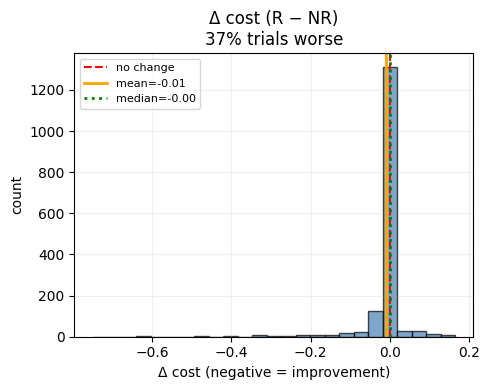

In [179]:
# ── Delta cost distribution: fraction worse, t-test, histogram ───────────────

from scipy import stats as sp_stats


d = np.array(all_d)
n = len(d)
frac_worse = float((d > 0).mean())
frac_better = float((d < 0).mean())
frac_tied = float((d == 0).mean())

# One-sample t-test: H0: mean(delta) = 0
t_stat, p_ttest = sp_stats.ttest_1samp(d, 0.0)

# Median
med = float(np.median(d))

# Percentiles
p5, p25, p75, p95 = np.percentile(d, [5, 25, 75, 95])

print(f"{'='*60}")
print(f"  mean ± std:  {d.mean():+.4f} ± {d.std(ddof=1):.4f}")
print(f"  median:      {med:+.4f}")
print(f"  percentiles: 5%={p5:+.4f}  25%={p25:+.4f}  75%={p75:+.4f}  95%={p95:+.4f}")
print(f"  trials better:  {frac_better*100:.1f}%  ({int(frac_better*n)}/{n})")
print(f"  trials worse:   {frac_worse*100:.1f}%  ({int(frac_worse*n)}/{n})")
print(f"  t-stat={t_stat:.3f},  p={p_ttest:.2e}")

print(f"{'='*60}")

# Histogram
fig, ax = plt.subplots(1, 1, figsize=(5, 4))


d = np.array(all_d)
ax.hist(d, bins=25, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="no change")
ax.axvline(d.mean(), color="orange", linestyle="-", linewidth=2, label=f"mean={d.mean():+.2f}")
ax.axvline(np.median(d), color="green", linestyle=":", linewidth=2, label=f"median={np.median(d):+.2f}")

frac_worse = (d > 0).mean()
ax.set_title(f"Δ cost (R − NR)\n{frac_worse*100:.0f}% trials worse")
ax.set_xlabel("Δ cost (negative = improvement)")
ax.set_ylabel("count")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [138]:

# Inspect per-step adaptation + solve times for one rollout
INSPECT_SCENARIO = scenarios[0]["name"]
INSPECT_TYPE = 0
INSPECT_POLICY = "resolve"   # "resolve" or "no_resolve"
INSPECT_TRIAL = 0

if INSPECT_POLICY == "resolve":
    entry = scenario_results[INSPECT_SCENARIO]["resolve_trials"][INSPECT_TYPE][INSPECT_TRIAL]
else:
    entry = scenario_results[INSPECT_SCENARIO]["no_resolve_trials"][INSPECT_TYPE][INSPECT_TRIAL]

ro = entry["rollout"]

if INSPECT_POLICY == "resolve":
    diag_rows = []
    for k, d in enumerate(ro["adaptation_diag"]):
        diag_rows.append(
            {
                "step": k+1, # from 2nd step
                "warm_loss": float(d["warm_loss"]),
                "final_loss": float(d["final_loss"]),
                "delta_loss": float(d["final_loss"] - d["warm_loss"]),
                "iters_run": int(d["iters_run"]),
                "early_stopped": bool(d["early_stopped"]),
                "converged": bool(d["converged"]),
                "solve_ms": float(d.get("solve_ms", ro["solve_times_ms"][k])),
            }
        )
    inspect_df = pd.DataFrame(diag_rows)
else:
    inspect_df = pd.DataFrame(
        [
            {
                "step": 0,
                "mode": "root solve only",
                "solve_ms": float(ro["total_solve_ms"]),
                "num_solves": int(ro["num_solves"]),
            }
        ]
    )

inspect_df


,step,warm_loss,final_loss,delta_loss,iters_run,early_stopped,converged,solve_ms
0,1,0.025592,0.025592,-2.495944e-07,5,True,True,137.476625
1,2,-0.171149,-0.171149,2.980232e-08,5,True,True,99.875500
2,3,0.015285,0.015285,-2.328306e-07,5,True,True,64.480208
3,4,-0.056752,-0.056752,-2.607703e-08,5,True,True,50.357792
4,5,-0.804713,-0.804713,5.960464e-08,5,True,True,39.661125
5,6,-0.086987,-0.086987,1.490116e-07,5,True,True,30.026791
6,7,-0.076757,-0.076757,2.384186e-07,5,True,True,22.511500
7,8,-1.229733,-1.229734,-1.192093e-06,5,True,True,15.739375
8,9,-0.643835,-0.643835,0.000000e+00,5,True,True,8.718583


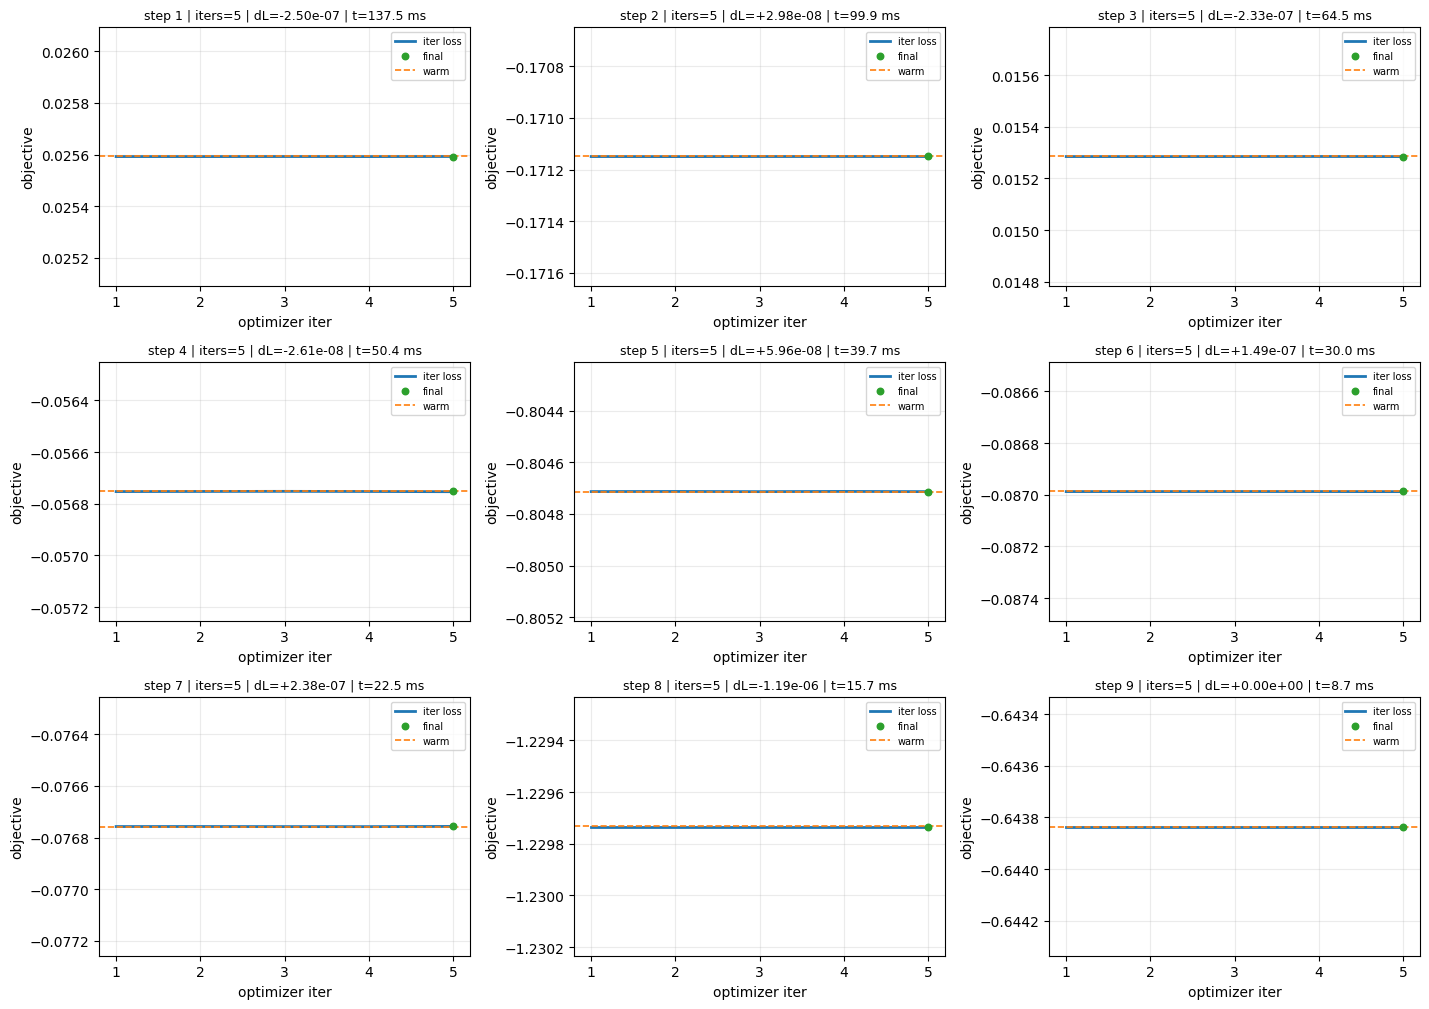

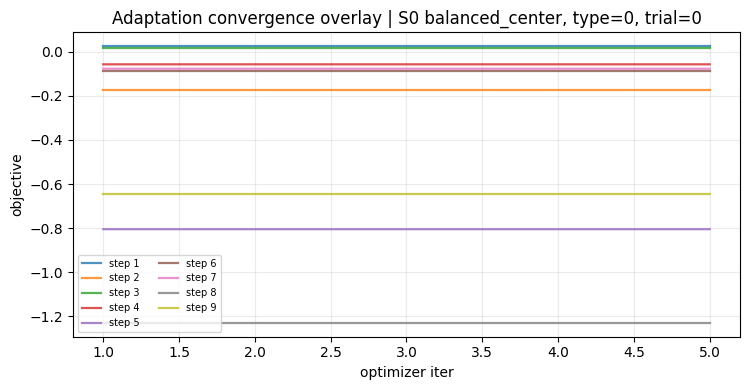

In [139]:

# Convergence plots for online adaptation solves (resolve mode only)
PLOT_SCENARIO = INSPECT_SCENARIO if "INSPECT_SCENARIO" in globals() else scenarios[0]["name"]
PLOT_TYPE = INSPECT_TYPE if "INSPECT_TYPE" in globals() else 0
PLOT_TRIAL = INSPECT_TRIAL if "INSPECT_TRIAL" in globals() else 0
PLOT_POLICY = INSPECT_POLICY if "INSPECT_POLICY" in globals() else "resolve"

# Increase this to avoid overly zoomed y-axis in flat convergence traces.
CONV_PLOT_MIN_Y_WINDOW = 1e-3


def _set_wider_y_axis(ax, values: np.ndarray, min_window: float):
    v = np.asarray(values, dtype=np.float64)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return
    vmin = float(v.min())
    vmax = float(v.max())
    center = 0.5 * (vmin + vmax)
    half_raw = 0.55 * max(vmax - vmin, 0.0)
    half = max(half_raw, 0.5 * float(min_window))
    ax.set_ylim(center - half, center + half)
    # Disable offset/scientific notation so scale is explicit.
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.yaxis.get_major_formatter().set_scientific(False)


if PLOT_POLICY != "resolve":
    print("Convergence curves are available only for resolve policy. Set INSPECT_POLICY='resolve'.")
else:
    diag = scenario_results[PLOT_SCENARIO]["resolve_trials"][PLOT_TYPE][PLOT_TRIAL]["rollout"]["adaptation_diag"]

    if len(diag) == 0:
        print("No adaptation steps recorded for this rollout.")
    else:
        n = len(diag)
        ncols = min(3, n)
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 3.4 * nrows), squeeze=False)

        for k in range(nrows * ncols):
            r, c = divmod(k, ncols)
            ax = axes[r, c]

            if k >= n:
                ax.axis("off")
                continue

            d = diag[k]
            lc = np.asarray(d.get("loss_curve", []), dtype=np.float64)
            warm = float(d.get("warm_loss", np.nan))
            final = float(d.get("final_loss", np.nan))
            solve_ms = float(d.get("solve_ms", np.nan))

            if lc.size > 0:
                it = np.arange(1, lc.size + 1)
                ax.plot(it, lc, color="tab:blue", linewidth=2.0, label="iter loss")
                ax.scatter([it[-1]], [final], color="tab:green", s=22, zorder=5, label="final")
            else:
                ax.text(0.5, 0.5, "no iterations", transform=ax.transAxes, ha="center", va="center")

            if np.isfinite(warm):
                ax.axhline(warm, color="tab:orange", linestyle="--", linewidth=1.2, label="warm")

            y_vals = lc.copy()
            if np.isfinite(warm):
                y_vals = np.append(y_vals, warm)
            if np.isfinite(final):
                y_vals = np.append(y_vals, final)
            _set_wider_y_axis(ax, y_vals, CONV_PLOT_MIN_Y_WINDOW)

            ax.set_title(
                f"step {k+1} | iters={int(d.get('iters_run', 0))} | "
                f"dL={final - warm:+.2e} | t={solve_ms:.1f} ms",
                fontsize=9,
            )
            ax.set_xlabel("optimizer iter")
            ax.set_ylabel("objective")
            ax.grid(True, alpha=0.25)
            ax.legend(fontsize=7, loc="best")

        plt.tight_layout()
        plt.show()

        # Aggregate view: all per-step curves overlaid
        fig, ax = plt.subplots(1, 1, figsize=(7.6, 4.0))
        all_overlay_vals = []
        for k, d in enumerate(diag):
            lc = np.asarray(d.get("loss_curve", []), dtype=np.float64)
            if lc.size == 0:
                continue
            it = np.arange(1, lc.size + 1)
            ax.plot(it, lc, linewidth=1.6, alpha=0.8, label=f"step {k+1}")
            all_overlay_vals.append(lc)

        if len(all_overlay_vals) > 0:
            _set_wider_y_axis(ax, np.concatenate(all_overlay_vals, axis=0), CONV_PLOT_MIN_Y_WINDOW)

        ax.set_title(f"Adaptation convergence overlay | {PLOT_SCENARIO}, type={PLOT_TYPE}, trial={PLOT_TRIAL}")
        ax.set_xlabel("optimizer iter")
        ax.set_ylabel("objective")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=7, ncol=2, loc="best")
        plt.tight_layout()
        plt.show()


In [140]:

# Numeric convergence check for each adaptation step (scale-free)
# Verifies the early-stop rule directly from loss curves.

CHECK_SCENARIO = INSPECT_SCENARIO if "INSPECT_SCENARIO" in globals() else scenarios[0]["name"]
CHECK_TYPE = INSPECT_TYPE if "INSPECT_TYPE" in globals() else 0
CHECK_TRIAL = INSPECT_TRIAL if "INSPECT_TRIAL" in globals() else 0
CHECK_POLICY = INSPECT_POLICY if "INSPECT_POLICY" in globals() else "resolve"

if CHECK_POLICY != "resolve":
    print("Convergence check is defined for resolve policy only. Set INSPECT_POLICY='resolve'.")
    conv_check_df = pd.DataFrame()
else:
    diag = scenario_results[CHECK_SCENARIO]["resolve_trials"][CHECK_TYPE][CHECK_TRIAL]["rollout"]["adaptation_diag"]

    rows = []
    for k, d in enumerate(diag, start=1):
        lc = np.asarray(d.get("loss_curve", []), dtype=np.float64)
        diffs = np.abs(np.diff(lc)) if lc.size >= 2 else np.asarray([], dtype=np.float64)

        p = int(ONLINE_ALPHA_PATIENCE)
        m = int(ONLINE_ALPHA_MIN_ITERS)
        tail = diffs[-p:] if diffs.size >= p and p > 0 else diffs

        rule_met_tail = bool(
            lc.size >= max(m, p + 1)
            and p > 0
            and tail.size == p
            and np.all(tail <= float(ONLINE_ALPHA_MIN_DELTA))
        )

        rows.append(
            {
                "step": int(k),
                "iters_run": int(d.get("iters_run", 0)),
                "early_stopped_flag": bool(d.get("early_stopped", False)),
                "rule_met_tail": bool(rule_met_tail),
                "tail_len": int(tail.size),
                "max_tail_abs_diff": float(np.max(tail)) if tail.size else np.nan,
                "mean_tail_abs_diff": float(np.mean(tail)) if tail.size else np.nan,
                "min_delta": float(ONLINE_ALPHA_MIN_DELTA),
                "warm_loss": float(d.get("warm_loss", np.nan)),
                "final_loss": float(d.get("final_loss", np.nan)),
                "final_minus_warm": float(d.get("final_loss", np.nan) - d.get("warm_loss", np.nan)),
                "best_iter_loss": float(np.min(lc)) if lc.size else np.nan,
                "final_minus_best_iter": float(lc[-1] - np.min(lc)) if lc.size else np.nan,
                "converged_flag": bool(d.get("converged", False)),
                "solve_ms": float(d.get("solve_ms", np.nan)),
            }
        )

    conv_check_df = pd.DataFrame(rows)

    # Summary counts for quick read.
    if len(conv_check_df) > 0:
        print(
            f"steps={len(conv_check_df)}, "
            f"early_stopped={int(conv_check_df['early_stopped_flag'].sum())}, "
            f"rule_met_tail={int(conv_check_df['rule_met_tail'].sum())}, "
            f"converged_flag={int(conv_check_df['converged_flag'].sum())}"
        )

conv_check_df


steps=9, early_stopped=9, rule_met_tail=9, converged_flag=9


,step,iters_run,early_stopped_flag,rule_met_tail,tail_len,max_tail_abs_diff,mean_tail_abs_diff,min_delta,warm_loss,final_loss,final_minus_warm,best_iter_loss,final_minus_best_iter,converged_flag,solve_ms
0,1,5,True,True,4,3.948808e-07,2.346933e-07,0.000001,0.025592,0.025592,-2.495944e-07,0.025592,3.948808e-07,True,137.476625
1,2,5,True,True,4,2.533197e-07,1.676381e-07,0.000001,-0.171149,-0.171149,2.980232e-08,-0.171150,3.129244e-07,True,99.875500
2,3,5,True,True,4,4.284084e-07,2.719462e-07,0.000001,0.015285,0.015285,-2.328306e-07,0.015285,4.842877e-08,True,64.480208
3,4,5,True,True,4,8.903444e-07,5.625188e-07,0.000001,-0.056752,-0.056752,-2.607703e-08,-0.056753,0.000000e+00,True,50.357792
4,5,5,True,True,4,8.344650e-07,7.152557e-07,0.000001,-0.804713,-0.804713,5.960464e-08,-0.804714,0.000000e+00,True,39.661125
5,6,5,True,True,4,3.576279e-07,1.713634e-07,0.000001,-0.086987,-0.086987,1.490116e-07,-0.086988,0.000000e+00,True,30.026791
6,7,5,True,True,4,8.344650e-07,3.576279e-07,0.000001,-0.076757,-0.076757,2.384186e-07,-0.076758,8.344650e-07,True,22.511500
7,8,5,True,True,4,0.000000e+00,0.000000e+00,0.000001,-1.229733,-1.229734,-1.192093e-06,-1.229734,0.000000e+00,True,15.739375
8,9,5,True,True,4,0.000000e+00,0.000000e+00,0.000001,-0.643835,-0.643835,0.000000e+00,-0.643835,0.000000e+00,True,8.718583


/var/folders/xd/5m8xqhxj7nb98dkg_t5fs5zc0000gq/T/ipykernel_31002/2801965322.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("turbo")


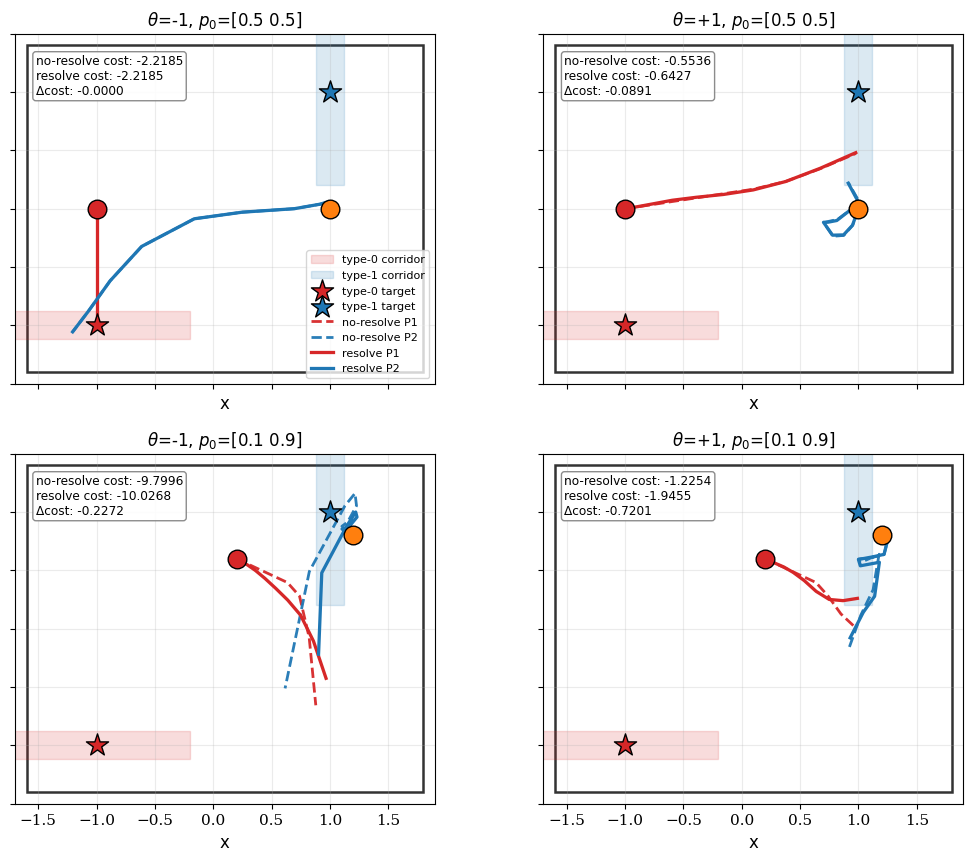

In [141]:

# Trajectory comparison under stochastic P2 dynamics:
# no-resolve (offline alpha fixed) vs resolve-each-step.
from types import SimpleNamespace

scenarios_new = [scenarios[0], scenarios[-1]]
num_rows = len(scenarios_new)
num_cols = game.I
fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 5 * num_rows), squeeze=False, sharex=True, sharey=True)
# fig, axes = plt.subplots(num_rows, num_cols, figsize=(7.4 * num_cols, 5.1 * num_rows), squeeze=False, sharex=True, sharey=True)

norm = plt.Normalize(vmin=0.0, vmax=1.0)
cmap = plt.cm.get_cmap("turbo")

for r, s in enumerate(scenarios_new):
    name = s["name"]
    prior_np = s["prior"].detach().cpu().numpy()

    for c in range(num_cols):
        ax = axes[r, c]

        no_entry = scenario_results[name]["no_resolve_trials"][c][5] #5
        rs_entry = scenario_results[name]["resolve_trials"][c][5]

        no_rollout = SimpleNamespace(**no_entry["rollout"])
        rs_rollout = SimpleNamespace(**rs_entry["rollout"])

        plot_hexner_mod_context(ax=ax, game=game, legend=False)

        plot_hexner_mod_trajectory(
            ax=ax,
            game=game,
            rollout=no_rollout,
            label_prefix="no-resolve",
            line_style="--",
            line_width=2.0,
            alpha=0.95,
            show_context=False,
            show_belief_markers=False,
            add_start_markers=False,
            legend=False,
        )
        plot_hexner_mod_trajectory(
            ax=ax,
            game=game,
            rollout=rs_rollout,
            label_prefix="resolve",
            line_style="-",
            line_width=2.35,
            alpha=1.0,
            show_context=False,
            show_belief_markers=False,
            belief_component=0,
            belief_label=r"$p(\theta_0)$",
            belief_cmap="turbo",
            belief_marker_size=62.0,
            belief_marker_alpha=0.95,
            belief_marker_perimeter_only=True,
            show_colorbar=False,
            add_start_markers=True,
            legend=False,
        )

        # Styling request: P2 is orange and uses circular start marker (not square).
        # for ln in ax.get_lines():
        #     label = ln.get_label() or ""
        #     if "P2" in label:
        #         ln.set_color("orange")

        x0_plot = rs_rollout.x_traj[0].detach().cpu().numpy()
        p1_start = x0_plot[:2]
        p2_start = x0_plot[game.cfg.dx1 : game.cfg.dx1 + 2]
        # ax.scatter(p1_start[0], p1_start[1], marker="o", s=170, color="tab:red", edgecolors="black", zorder=7)
        # ax.scatter(p2_start[0], p2_start[1], marker="o", s=170, color="tab:orange", edgecolors="black", zorder=7)

        no_cost = float(no_entry["cost"])
        rs_cost = float(rs_entry["cost"])

        ax.text(
            0.05,
            0.94,
            f"no-resolve cost: {no_cost:.4f}\n"
            f"resolve cost: {rs_cost:.4f}\n"
            f"Δcost: {rs_cost - no_cost:.4f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8.7,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.9),
            zorder=10,
        )

        ax.set_title(f"$\\theta$={float(game.theta_vals[c]):+.0f}, $p_0$={prior_np.round(2)}") #{name} | 

        if r == 0 and c == 0:
            ax.legend(fontsize=8, loc="lower right")

# sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.32, pad=-0.5)
# cbar.set_label(r"$p(\theta_0)$")
# plt.subplots_adjust(wspace=0.05)
# plt.subplots_adjust(wspace=-0.3)
plt.subplots_adjust(wspace=-0.05)
# plt.subplots_adjust(wspace=0.04, hspace=0.05)

# plt.tight_layout()
axes[0, 1].set_ylabel('')
axes[1, 1].set_ylabel('')
axes[0, 0].set_ylabel('')
axes[1, 0].set_ylabel('')

axes[0, 1].set_yticklabels([])
axes[1, 1].set_yticklabels([])
axes[0, 0].set_yticklabels([])
axes[1, 0].set_yticklabels([])

# sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=axes[:, :], location='right', shrink=0.32, pad=0.01)
# cbar.set_label(r"$p(\theta=-1)$")

# plt.savefig('drone_noisy_new.png', dpi=600)
plt.show()


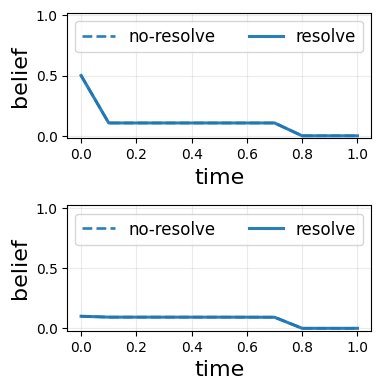

In [144]:

# Belief trajectories: no-resolve vs resolve (trial 0), p(theta_0)
# fig, axes = plt.subplots(len(scenarios), 1, figsize=(11, 3.2 * len(scenarios)), squeeze=False)
fig, axes = plt.subplots(len(scenarios_new), 1, figsize=(4, 2 * len(scenarios_new)), squeeze=False)

for r, s in enumerate(scenarios_new):
    name = s["name"]
    ax = axes[r, 0]

    for type_idx, color in [(0, "tab:red"), (1, "tab:blue")]:
        b_no = scenario_results[name]["no_resolve_trials"][type_idx][1]["rollout"]["belief_traj"].detach().cpu().numpy()
        b_rs = scenario_results[name]["resolve_trials"][type_idx][1]["rollout"]["belief_traj"].detach().cpu().numpy()

        t_no = np.linspace(0.0, float(game_cfg.T), b_no.shape[0])
        t_rs = np.linspace(0.0, float(game_cfg.T), b_rs.shape[0])

        if type_idx == 1:
            ax.plot(t_no, b_no[:, 0], "--", color=color, linewidth=1.9, alpha=0.95, label=f"no-resolve")
            ax.plot(t_rs, b_rs[:, 0], "-", color=color, linewidth=2.2, alpha=0.95, label=f"resolve")

    ax.set_ylim(-0.02, 1.02)
    # ax.set_title(f"Belief trajectories | {name}")
    ax.set_xlabel("time", fontsize=16)
    ax.set_ylabel(r"belief", fontsize=16)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=12, ncol=2, loc="best")

plt.tight_layout()
# plt.savefig('belief_noise_2.png', dpi=600)
plt.show()


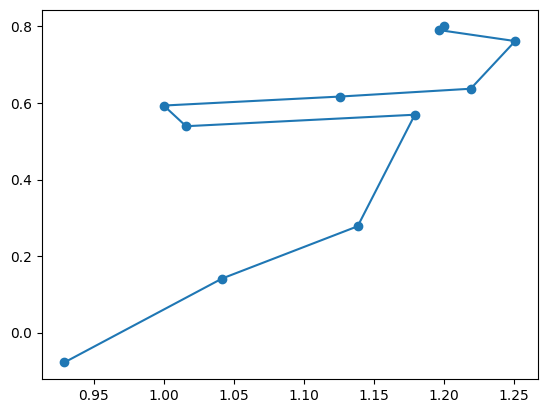

In [172]:
# plt.plot(rs_rollout.x_traj[:, 4], rs_rollout.x_traj[:, 5])
# plt.plot(rs_rollout.x_traj[:, 6], rs_rollout.x_traj[:, 7], 'o-', label='velocity')
# plt.plot(rs_rollout.x_traj[0, 6], rs_rollout.x_traj[0, 7], color='red', marker='x', markersize=10, label = 'start')
# plt.plot(rs_rollout.w_traj[:, -2], rs_rollout.w_traj[:, -1], label='noise')
# plt.legend()
# plt.hist(rs_rollout.w_traj[:, -2])
# plt.hist(rs_rollout.w_traj[:, -1])

plt.plot(rs_rollout.x_traj[:, 4], rs_rollout.x_traj[:, 5], 'o-')

In [169]:
rs_rollout.x_traj[:, 4:], rs_rollout.v_traj, rs_rollout.w_traj

(tensor([[ 1.2000,  0.8000,  0.0000,  0.0000],
         [ 1.1968,  0.7906,  0.6897, -0.1984],
         [ 1.2510,  0.7618, -0.3069, -1.3593],
         [ 1.2192,  0.6373, -1.0787, -0.0631],
         [ 1.1259,  0.6169, -1.5616, -0.0143],
         [ 0.9999,  0.5934,  0.2269, -0.3209],
         [ 1.0159,  0.5393,  2.4241,  0.7901],
         [ 1.1793,  0.5694, -0.2904, -3.2780],
         [ 1.1385,  0.2778, -1.1767, -1.5482],
         [ 1.0416,  0.1412, -1.3054, -2.2613],
         [ 0.9288, -0.0782, -0.1886, -3.0019]]),
 tensor([[ -0.6436,  -1.8834],
         [ -2.9447,  -1.7837],
         [ -0.2186,   2.2810],
         [  2.9073,  -2.8275],
         [  6.0305,  -4.4118],
         [ -1.3479,  -4.3885],
         [-15.7878,  -9.7905],
         [ -2.3646,   7.2513],
         [  4.1512,   3.6417],
         [  3.5593,   1.3477]]),
 tensor([[ 0.0000,  0.0000,  0.0000, -0.0000, -0.0000,  0.0000,  0.7540, -0.0101],
         [-0.0000, -0.0000, -0.0000,  0.0000, -0.0000, -0.0000, -0.7021, -0.9825],
   

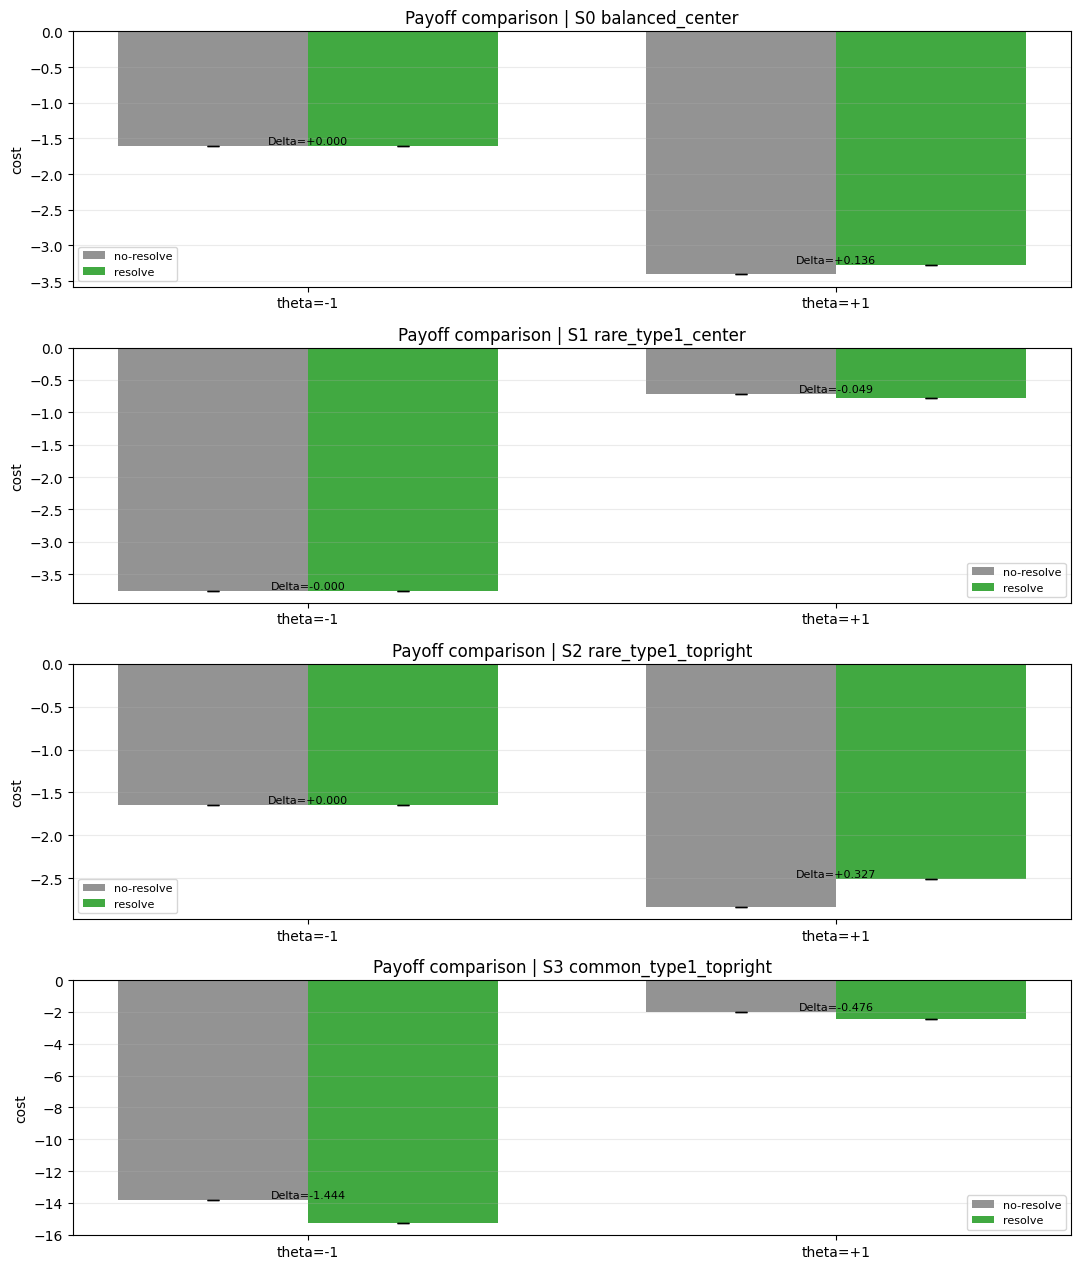

In [294]:

# Payoff comparison (mean +/- std across trials): no-resolve vs resolve.
fig, axes = plt.subplots(len(scenarios), 1, figsize=(11, 3.2 * len(scenarios)), squeeze=False)

for r, s in enumerate(scenarios):
    name = s["name"]
    ax = axes[r, 0]

    type_ids = np.arange(game.I)
    no_means = [scenario_results[name]["no_resolve_stats"][i]["mean"] for i in range(game.I)]
    no_stds = [scenario_results[name]["no_resolve_stats"][i]["std"] for i in range(game.I)]
    rs_means = [scenario_results[name]["resolve_stats"][i]["mean"] for i in range(game.I)]
    rs_stds = [scenario_results[name]["resolve_stats"][i]["std"] for i in range(game.I)]

    width = 0.36
    ax.bar(type_ids - width / 2, no_means, width, yerr=no_stds, capsize=4, alpha=0.85, color="gray", label="no-resolve")
    ax.bar(type_ids + width / 2, rs_means, width, yerr=rs_stds, capsize=4, alpha=0.9, color="tab:green", label="resolve")

    for i in range(game.I):
        d = rs_means[i] - no_means[i]
        ax.text(i, max(no_means[i], rs_means[i]), f"Delta={d:+.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(type_ids)
    ax.set_xticklabels([f"theta={float(game.theta_vals[i]):+.0f}" for i in range(game.I)])
    ax.set_ylabel("cost")
    ax.set_title(f"Payoff comparison | {name}")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()


Sample: scenario='S0 balanced_center', type=0, mode='resolve', trial=0
Horizon K=10, state dim=8
max|residual - w_logged| = 1.192e-07
rms(residual - w_logged) = 1.955e-08
rms(residual on noisy dims) = 8.956e-01
max|residual on masked-off dims| = 0.000e+00


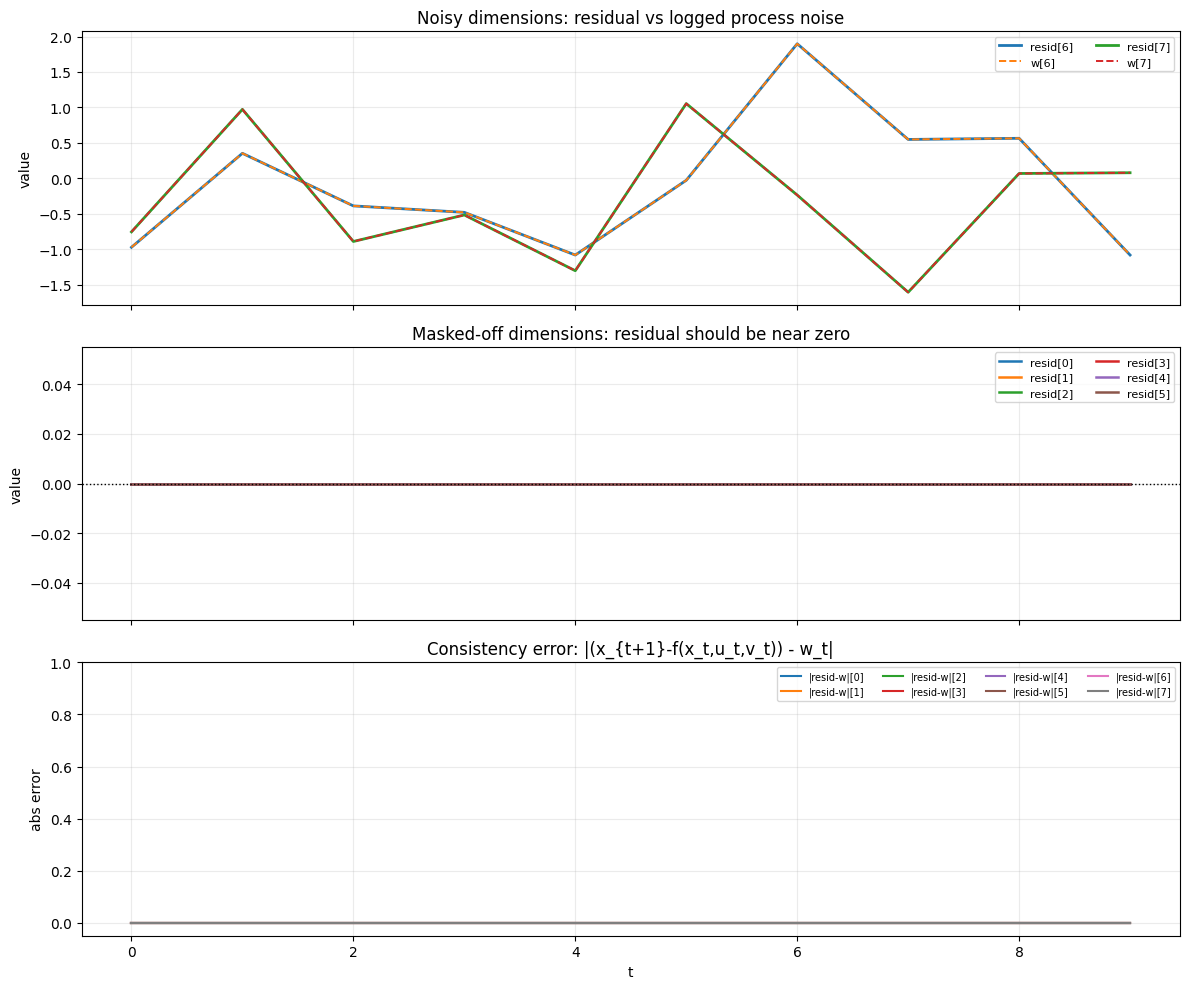

In [146]:
# Diagnostics: residual-vs-noise check for one selectable rollout sample.
# This helps verify jumpy trajectories are consistent with injected process noise,
# not a state-update bug.

def plot_rollout_noise_diagnostics(
    scenario_name: str | None = None,
    type_idx: int = 0,
    mode: str = "resolve",  # "resolve" or "no_resolve"
    trial_idx: int = 0,
):
    if "scenario_results" not in globals():
        raise RuntimeError("scenario_results not found. Run the rollout experiment cell first.")

    scenario_names = list(scenario_results.keys())
    if len(scenario_names) == 0:
        raise RuntimeError("scenario_results is empty.")

    if scenario_name is None:
        scenario_name = scenario_names[0]
    if scenario_name not in scenario_results:
        raise KeyError(f"Unknown scenario '{scenario_name}'. Available: {scenario_names}")

    mode = str(mode).lower().strip()
    if mode not in ("resolve", "no_resolve"):
        raise ValueError("mode must be 'resolve' or 'no_resolve'.")

    mode_key = f"{mode}_trials"
    by_type = scenario_results[scenario_name][mode_key]
    type_idx = int(type_idx)
    if type_idx not in by_type:
        raise KeyError(f"type_idx={type_idx} missing for scenario '{scenario_name}', mode '{mode}'.")

    trials = by_type[type_idx]
    trial_idx = int(trial_idx)
    if not (0 <= trial_idx < len(trials)):
        raise IndexError(f"trial_idx must be in [0, {len(trials)-1}], got {trial_idx}.")

    ro = trials[trial_idx]["rollout"]
    x = ro["x_traj"]  # (K+1, dx)
    u = ro["u_traj"]  # (K, du)
    v = ro["v_traj"]  # (K, dv)
    w_logged = ro.get("w_traj", None)

    K = int(u.shape[0])
    x_det = torch.stack([game.step_dynamics(x[t], u[t], v[t]) for t in range(K)], dim=0)
    resid = x[1:] - x_det

    has_w = w_logged is not None
    if not has_w:
        w_logged = torch.zeros_like(resid)

    diff = resid - w_logged

    if "dyn_noise_mask" in globals():
        mask = dyn_noise_mask.to(device=resid.device, dtype=resid.dtype)
    else:
        mask = torch.ones(resid.shape[-1], device=resid.device, dtype=resid.dtype)

    noisy_idx = torch.where(mask > 0.5)[0].tolist()
    quiet_idx = torch.where(mask <= 0.5)[0].tolist()

    abs_diff = diff.abs()
    max_abs_diff = float(abs_diff.max().detach().cpu().item())
    rms_diff = float(torch.sqrt((diff * diff).mean()).detach().cpu().item())

    noisy_rms = float(torch.sqrt((resid[:, noisy_idx] ** 2).mean()).detach().cpu().item()) if len(noisy_idx) > 0 else 0.0
    quiet_max = float(resid[:, quiet_idx].abs().max().detach().cpu().item()) if len(quiet_idx) > 0 else 0.0

    print(f"Sample: scenario='{scenario_name}', type={type_idx}, mode='{mode}', trial={trial_idx}")
    print(f"Horizon K={K}, state dim={resid.shape[-1]}")
    print(f"max|residual - w_logged| = {max_abs_diff:.3e}")
    print(f"rms(residual - w_logged) = {rms_diff:.3e}")
    print(f"rms(residual on noisy dims) = {noisy_rms:.3e}")
    print(f"max|residual on masked-off dims| = {quiet_max:.3e}")

    t = np.arange(K)
    resid_np = resid.detach().cpu().numpy()
    w_np = w_logged.detach().cpu().numpy()
    diff_np = diff.detach().cpu().numpy()

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    # 1) Noisy dims: residual vs logged noise.
    if len(noisy_idx) == 0:
        axes[0].text(0.5, 0.5, "No noisy dims in dyn_noise_mask.", ha="center", va="center", transform=axes[0].transAxes)
    else:
        for d in noisy_idx:
            axes[0].plot(t, resid_np[:, d], linewidth=2.0, label=f"resid[{d}]")
            if has_w:
                axes[0].plot(t, w_np[:, d], "--", linewidth=1.4, label=f"w[{d}]")
    axes[0].set_ylabel("value")
    axes[0].set_title("Noisy dimensions: residual vs logged process noise")
    axes[0].grid(True, alpha=0.25)
    if len(noisy_idx) > 0:
        axes[0].legend(ncol=2, fontsize=8, loc="upper right")

    # 2) Masked-off dims: should stay near zero.
    if len(quiet_idx) == 0:
        axes[1].text(0.5, 0.5, "All dims are noisy in dyn_noise_mask.", ha="center", va="center", transform=axes[1].transAxes)
    else:
        for d in quiet_idx:
            axes[1].plot(t, resid_np[:, d], linewidth=1.8, label=f"resid[{d}]")
        axes[1].axhline(0.0, color="black", linestyle=":", linewidth=1.0)
    axes[1].set_ylabel("value")
    axes[1].set_title("Masked-off dimensions: residual should be near zero")
    axes[1].grid(True, alpha=0.25)
    if len(quiet_idx) > 0:
        axes[1].legend(ncol=2, fontsize=8, loc="upper right")

    # 3) Residual-minus-logged-noise consistency error.
    for d in range(resid_np.shape[1]):
        axes[2].plot(t, np.abs(diff_np[:, d]), linewidth=1.5, label=f"|resid-w|[{d}]")
    axes[2].set_ylabel("abs error")
    axes[2].set_xlabel("t")
    axes[2].set_title("Consistency error: |(x_{t+1}-f(x_t,u_t,v_t)) - w_t|")
    axes[2].grid(True, alpha=0.25)
    axes[2].legend(ncol=4, fontsize=7, loc="upper right")
    axes[2].set_ylim([-0.05, 1])

    plt.tight_layout()
    plt.show()


# ---- Select sample here ----
DIAG_SCENARIO = list(scenario_results.keys())[0]
DIAG_TYPE = 0
DIAG_MODE = "resolve"      # "resolve" or "no_resolve"
DIAG_TRIAL = 0

plot_rollout_noise_diagnostics(
    scenario_name=DIAG_SCENARIO,
    type_idx=DIAG_TYPE,
    mode=DIAG_MODE,
    trial_idx=DIAG_TRIAL,
)


### Notes
- This notebook uses **re-solve every timestep** under noisy observation.
- Belief is updated by Bayes from the selected signaling branch.
- To increase statistical confidence, raise `NUM_NOISE_TRIALS`.
- To test stronger corruption, increase `OBS_NOISE_STD` or use `OBS_NOISE_MODE = "all"`.
- The rollout enforces exactly one re-solve per step (`num_replans == K`) and raises if violated.
- `exact` now uses the same one-shot `rollout_trajectory` path as the existing rollout notebooks.
- `exact_replan` is reported separately to sanity-check receding-horizon behavior at zero noise.
- Plot cells use `EXACT_REFERENCE` (default `"replan"`) so belief comparisons align with re-solve-every-step semantics.
- If belief does not move under noise, often `alpha` is effectively pooling at many steps.
- Per-step adaptation diagnostics are available in `step_diag_df` (`delta_loss`, `iters_run`, `converged`).
- Now each step solves on the remaining subtree by rebasing alpha along the realized path; unreachable nodes are dropped via the shorter indexer.
- At each step, remaining subtree logits are optimized online for `ONLINE_ALPHA_ITERS` before applying the root action.
- Per-step optimization diagnostics are available in `step_diag_df` and aggregated in `summary_df` step columns.
